In [1]:
import sys
import qiskit
import qiskit_aer

print("Python executable:", sys.executable)
print("Qiskit:", qiskit.__version__)
print("Qiskit Aer:", qiskit_aer.__version__)

Python executable: D:\Anaconda\envs\qiskit\python.exe
Qiskit: 2.5.2
Qiskit Aer: 0.17.2


In [2]:
from qiskit import QuantumCircuit

bell = QuantumCircuit(2)

bell.h(0)
bell.cx(0, 1)

bell.measure_all()

print(bell)

        ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 


In [3]:
from qiskit_aer import AerSimulator

ideal_simulator = AerSimulator()

print("Ideal simulator created successfully.")

Ideal simulator created successfully.


In [4]:
from qiskit import transpile

ideal_circuit = transpile(bell, ideal_simulator)

print(ideal_circuit)

        ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 


In [5]:
SHOTS = 1024

ideal_result = ideal_simulator.run(
    ideal_circuit,
    shots=SHOTS,
    seed_simulator=42
).result()

ideal_counts = ideal_result.get_counts()

print(ideal_counts)

{'00': 521, '11': 503}


In [6]:
# Calculate the fraction of measurements that produced
# the expected Bell-state outcomes: |00> and |11>.
ideal_fidelity = (
    ideal_counts.get("00", 0) +  # Number of |00> measurements
    ideal_counts.get("11", 0)    # Number of |11> measurements
) / SHOTS                         # Divide by total number of shots

# Display the calculated ideal fidelity
print("Ideal Bell-state fidelity:", ideal_fidelity)

Ideal Bell-state fidelity: 1.0


In [7]:
# Import Qiskit's noise-model tools.
# NoiseModel stores the errors that we want to simulate.
# depolarizing_error creates a depolarizing quantum error.
from qiskit_aer.noise import NoiseModel, depolarizing_error

# Define the probability of the simulated depolarizing error.
# 0.02 corresponds to a 2% error probability.
NOISE_PROBABILITY = 0.02

# Create an empty noise model.
noise_model = NoiseModel()

# Create a depolarizing error for a 2-qubit gate.
# The second argument, 2, means the error acts on two qubits.
cx_error = depolarizing_error(
    NOISE_PROBABILITY,
    2
)

# Apply this error to every CX gate in the simulated backend.
noise_model.add_all_qubit_quantum_error(
    cx_error,
    ["cx"]
)

print("Noise model created successfully.")
print("CX depolarizing error probability:", NOISE_PROBABILITY)

Noise model created successfully.
CX depolarizing error probability: 0.02


In [8]:
# Create an Aer simulator that uses our custom noise model.
# This makes the simulator behave like a simplified noisy quantum device.
noisy_simulator = AerSimulator(
    noise_model=noise_model
)

# Transpile the Bell circuit specifically for the noisy simulator.
# Transpilation converts the circuit into instructions suitable
# for the selected simulator/backend.
noisy_circuit = transpile(
    bell,
    noisy_simulator
)

print("Noisy simulator created successfully.")
print(noisy_circuit)

Noisy simulator created successfully.
global phase: π/4
        ┌─────────┐┌────┐┌─────────┐      ░ ┌─┐   
   q_0: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──■───░─┤M├───
        └─────────┘└────┘└─────────┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ────────────────────────────┤ X ├─░──╫─┤M├
                                    └───┘ ░  ║ └╥┘
meas: 2/═════════════════════════════════════╩══╩═
                                             0  1 


In [9]:
# Run the transpiled Bell circuit on the noisy simulator.
# The simulator will apply the 2% depolarizing noise
# that we attached to the CX gate.
noisy_result = noisy_simulator.run(
    noisy_circuit,
    shots=SHOTS,              # Use the same 1024 shots as the ideal experiment
    seed_simulator=42         # Fixed seed makes the experiment reproducible
).result()

# Extract the measurement counts from the simulation result.
noisy_counts = noisy_result.get_counts()

# Display the noisy measurement results.
print("Noisy measurement counts:")
print(noisy_counts)

Noisy measurement counts:
{'11': 494, '00': 520, '10': 4, '01': 6}


In [10]:
# Count the measurements that match the expected Bell-state outcomes.
# For our Bell circuit, the expected outcomes are only |00> and |11>.
noisy_fidelity = (
    noisy_counts.get("00", 0) +  # Correct |00> measurements
    noisy_counts.get("11", 0)    # Correct |11> measurements
) / SHOTS                         # Divide by the total number of measurements

# Calculate how much reliability was lost compared with the ideal result.
# The ideal fidelity was 1.0 for this experiment.
reliability_loss = ideal_fidelity - noisy_fidelity

# Display the results.
print("Ideal Bell-state fidelity:", ideal_fidelity)
print("Noisy Bell-state fidelity:", noisy_fidelity)
print("Reliability loss:", reliability_loss)

Ideal Bell-state fidelity: 1.0
Noisy Bell-state fidelity: 0.990234375
Reliability loss: 0.009765625


In [11]:
# Count all measurements that produced the expected Bell-state outcomes.
correct_measurements = (
    noisy_counts.get("00", 0) +
    noisy_counts.get("11", 0)
)

# Count measurements that produced unexpected outcomes.
incorrect_measurements = (
    noisy_counts.get("01", 0) +
    noisy_counts.get("10", 0)
)

# Convert the reliability loss from a fraction to percentage points.
reliability_loss_percent = reliability_loss * 100

# Calculate the percentage of measurements that were incorrect.
incorrect_measurement_percent = (
    incorrect_measurements / SHOTS
) * 100

# Display the engineering metrics.
print("Correct measurements:", correct_measurements)
print("Incorrect measurements:", incorrect_measurements)
print("Noisy fidelity:", noisy_fidelity)
print("Reliability loss:", reliability_loss)
print("Reliability loss (%):", reliability_loss_percent)
print("Incorrect measurement rate (%):", incorrect_measurement_percent)

Correct measurements: 1014
Incorrect measurements: 10
Noisy fidelity: 0.990234375
Reliability loss: 0.009765625
Reliability loss (%): 0.9765625
Incorrect measurement rate (%): 0.9765625


In [12]:
def calculate_bell_fidelity(counts, shots):
    """
    Calculate the Bell-state fidelity used in our experiment.

    For the Bell state created by our circuit, the expected
    measurement outcomes are |00> and |11>.
    """

    # Get the number of correct |00> measurements.
    count_00 = counts.get("00", 0)

    # Get the number of correct |11> measurements.
    count_11 = counts.get("11", 0)

    # Calculate the fraction of measurements that were correct.
    fidelity = (count_00 + count_11) / shots

    # Return the calculated fidelity.
    return fidelity


# Test the function using our already obtained noisy results.
test_fidelity = calculate_bell_fidelity(
    noisy_counts,
    SHOTS
)

print("Fidelity calculated using the reusable function:", test_fidelity)

Fidelity calculated using the reusable function: 0.990234375


In [13]:
# Make a copy of the original Bell circuit.
# We keep the original circuit unchanged so that we can
# compare the original and folded versions.
folded_bell = bell.copy()

# Find the CX gate and replace it with three CX gates.
# Since CX is self-inverse:
# CX · CX · CX = CX
# Therefore, the ideal computation remains equivalent,
# while the number of noisy CX operations increases.
folded_bell.data = [
    instruction for instruction in folded_bell.data
    if instruction.operation.name != "cx"
]

# Rebuild the circuit with the original H and measurement operations
# plus three CX gates.
folded_bell = QuantumCircuit(2)
folded_bell.h(0)

# Gate folding: CX -> CX CX CX
folded_bell.cx(0, 1)
folded_bell.cx(0, 1)
folded_bell.cx(0, 1)

# Measure both qubits.
folded_bell.measure_all()

# Display the folded circuit.
print(folded_bell)

        ┌───┐                ░ ┌─┐   
   q_0: ┤ H ├──■────■────■───░─┤M├───
        └───┘┌─┴─┐┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├┤ X ├┤ X ├─░──╫─┤M├
             └───┘└───┘└───┘ ░  ║ └╥┘
meas: 2/════════════════════════╩══╩═
                                0  1 


In [14]:
# Transpile the folded circuit for the noisy simulator.
# This converts the circuit into instructions supported by
# the backend while preserving the intended computation.
folded_noisy_circuit = transpile(
    folded_bell,
    noisy_simulator
)

# Display the transpiled folded circuit.
print(folded_noisy_circuit)

global phase: π/4
        ┌─────────┐┌────┐┌─────────┐      ░ ┌─┐   
   q_0: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──■───░─┤M├───
        └─────────┘└────┘└─────────┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ────────────────────────────┤ X ├─░──╫─┤M├
                                    └───┘ ░  ║ └╥┘
meas: 2/═════════════════════════════════════╩══╩═
                                             0  1 


In [15]:
# Transpile the folded circuit with optimization disabled.
# This is important because we intentionally added repeated CX gates
# for Zero-Noise Extrapolation (ZNE).
folded_noisy_circuit = transpile(
    folded_bell,
    noisy_simulator,
    optimization_level=0
)

# Display the transpiled circuit so we can verify
# that all three CX gates are still present.
print(folded_noisy_circuit)

global phase: π/4
        ┌─────────┐┌────┐┌─────────┐                ░ ┌─┐   
   q_0: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──■────■────■───░─┤M├───
        └─────────┘└────┘└─────────┘┌─┴─┐┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐
   q_1: ────────────────────────────┤ X ├┤ X ├┤ X ├─░──╫─┤M├
                                    └───┘└───┘└───┘ ░  ║ └╥┘
meas: 2/═══════════════════════════════════════════════╩══╩═
                                                       0  1 


In [16]:
# Execute the folded circuit using the same noisy simulator.
# Because the circuit contains three CX gates, the same
# CX noise model can act three times instead of once.
folded_result = noisy_simulator.run(
    folded_noisy_circuit,
    shots=SHOTS,              # Keep the same 1024 shots for fair comparison
    seed_simulator=42         # Keep the same seed for reproducibility
).result()

# Extract the measurement counts.
folded_counts = folded_result.get_counts()

# Display the results.
print("Folded-circuit measurement counts:")
print(folded_counts)

Folded-circuit measurement counts:
{'11': 488, '00': 508, '01': 18, '10': 10}


In [17]:
# Calculate the Bell-state fidelity for the folded circuit.
# This uses the same reliability metric as the original noisy circuit,
# so the comparison remains fair.
folded_fidelity = calculate_bell_fidelity(
    folded_counts,
    SHOTS
)

# Calculate the percentage of incorrect measurements.
folded_incorrect_measurements = (
    folded_counts.get("01", 0) +
    folded_counts.get("10", 0)
)

folded_incorrect_rate = (
    folded_incorrect_measurements / SHOTS
) * 100

# Display the scale-3 results.
print("Scale-3 Bell-state fidelity:", folded_fidelity)
print("Scale-3 incorrect measurements:", folded_incorrect_measurements)
print("Scale-3 incorrect measurement rate (%):", folded_incorrect_rate)

Scale-3 Bell-state fidelity: 0.97265625
Scale-3 incorrect measurements: 28
Scale-3 incorrect measurement rate (%): 2.734375


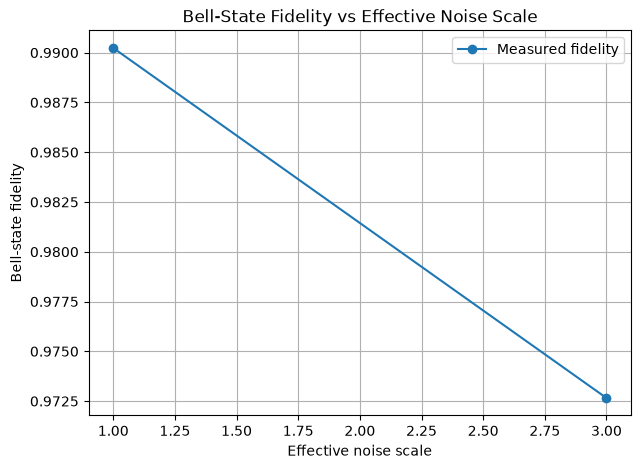

In [18]:
# Import matplotlib for visualization.
import matplotlib.pyplot as plt

# Define the noise scales we have experimentally tested.
noise_scales = [1, 3]

# Store the measured fidelities at those noise scales.
fidelities = [
    noisy_fidelity,      # Fidelity at 1x noise
    folded_fidelity      # Fidelity at 3x noise
]

# Create the plot.
plt.figure(figsize=(7, 5))

# Plot the measured fidelity values.
plt.plot(
    noise_scales,
    fidelities,
    marker="o",
    label="Measured fidelity"
)

# Add labels to the axes.
plt.xlabel("Effective noise scale")
plt.ylabel("Bell-state fidelity")

# Add a descriptive title.
plt.title("Bell-State Fidelity vs Effective Noise Scale")

# Add a grid to make the values easier to read.
plt.grid(True)

# Display the legend.
plt.legend()

# Display the graph.
plt.show()

In [19]:
# Create a new circuit for the 5x noise-scale experiment.
# We keep the previous 1x and 3x circuits unchanged.
folded_5x_bell = QuantumCircuit(2)

# Create the same Bell-state preparation.
folded_5x_bell.h(0)

# Gate folding at scale 5:
# CX -> CX CX CX CX CX
#
# Because CX is self-inverse:
# CX^5 = CX
#
# Therefore, the ideal computation is equivalent to the
# original Bell circuit, but the circuit experiences
# noise on five CX operations.
for _ in range(5):
    folded_5x_bell.cx(0, 1)

# Measure both qubits.
folded_5x_bell.measure_all()

# Display the circuit so we can verify the five CX gates.
print(folded_5x_bell)

        ┌───┐                          ░ ┌─┐   
   q_0: ┤ H ├──■────■────■────■────■───░─┤M├───
        └───┘┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├─░──╫─┤M├
             └───┘└───┘└───┘└───┘└───┘ ░  ║ └╥┘
meas: 2/══════════════════════════════════╩══╩═
                                          0  1 


In [20]:
# Transpile the 5x folded circuit for our noisy simulator.
#
# optimization_level=0 is important here.
# If optimization were enabled, Qiskit could simplify:
#
# CX CX CX CX CX  →  CX
#
# That would destroy our intended 5x noise scaling.
folded_5x_noisy_circuit = transpile(
    folded_5x_bell,
    noisy_simulator,
    optimization_level=0
)

# Display the transpiled circuit so we can verify
# that all five CX gates are still present.
print(folded_5x_noisy_circuit)

global phase: π/4
        ┌─────────┐┌────┐┌─────────┐                          ░ ┌─┐   
   q_0: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├──■────■────■────■────■───░─┤M├───
        └─────────┘└────┘└─────────┘┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐ ░ └╥┘┌─┐
   q_1: ────────────────────────────┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├─░──╫─┤M├
                                    └───┘└───┘└───┘└───┘└───┘ ░  ║ └╥┘
meas: 2/═════════════════════════════════════════════════════════╩══╩═
                                                                 0  1 


In [21]:
# Run the 5x folded circuit on the same noisy simulator.
#
# We keep the same number of shots (1024) so that the
# 1x, 3x, and 5x experiments are directly comparable.
# The same seed also makes this experiment reproducible.
folded_5x_result = noisy_simulator.run(
    folded_5x_noisy_circuit,
    shots=SHOTS,
    seed_simulator=42
).result()

# Extract the measurement counts from the simulation result.
folded_5x_counts = folded_5x_result.get_counts()

# Display the measurement results.
print("5x folded-circuit measurement counts:")
print(folded_5x_counts)

5x folded-circuit measurement counts:
{'11': 475, '00': 499, '01': 27, '10': 23}


In [22]:
# Calculate the Bell-state fidelity for the 5x noise scale.
#
# The correct Bell-state outcomes are:
#   00 -> correct
#   11 -> correct
#
# The incorrect outcomes are:
#   01
#   10
folded_5x_fidelity = (
    folded_5x_counts.get("00", 0) +
    folded_5x_counts.get("11", 0)
) / SHOTS

# Count the incorrect measurements.
folded_5x_incorrect = (
    folded_5x_counts.get("01", 0) +
    folded_5x_counts.get("10", 0)
)

# Calculate the incorrect measurement percentage.
folded_5x_incorrect_rate = (
    folded_5x_incorrect / SHOTS
) * 100

# Display the results.
print("Scale-5 Bell-state fidelity:", folded_5x_fidelity)
print("Scale-5 incorrect measurements:", folded_5x_incorrect)
print("Scale-5 incorrect measurement rate (%):", folded_5x_incorrect_rate)

Scale-5 Bell-state fidelity: 0.951171875
Scale-5 incorrect measurements: 50
Scale-5 incorrect measurement rate (%): 4.8828125


In [23]:
# Import NumPy for numerical calculations and linear fitting.
import numpy as np

# Define the effective noise scales used in our experiment.
# We intentionally tested 1x, 3x, and 5x noise exposure.
noise_scales = np.array([1, 3, 5])

# Store the experimentally measured Bell-state fidelities.
fidelities = np.array([
    noisy_fidelity,          # Fidelity at 1x noise
    folded_fidelity,         # Fidelity at 3x noise
    folded_5x_fidelity       # Fidelity at 5x noise
])

# Fit a straight line:
#
#     F(s) = a + b*s
#
# np.polyfit returns [b, a].
slope, intercept = np.polyfit(
    noise_scales,
    fidelities,
    1
)

# Evaluate the fitted line at s = 0.
# This represents our estimated zero-noise fidelity.
zne_fidelity = intercept

# Display the fitted model parameters.
print("ZNE slope:", slope)
print("ZNE intercept:", intercept)

# Display the estimated fidelity at zero noise.
print("ZNE estimated zero-noise fidelity:", zne_fidelity)

ZNE slope: -0.009765625000000036
ZNE intercept: 1.0006510416666663
ZNE estimated zero-noise fidelity: 1.0006510416666663


In [24]:
# Calculate the raw improvement produced by ZNE.
#
# We compare the zero-noise extrapolated estimate against
# the original noisy result at scale 1.
mitigation_gain = zne_fidelity - noisy_fidelity

# Calculate the relative improvement as a percentage.
relative_improvement = (
    mitigation_gain / noisy_fidelity
) * 100

# Because fidelity cannot physically exceed 1,
# define a physically bounded reporting value.
bounded_zne_fidelity = min(max(zne_fidelity, 0.0), 1.0)

# Calculate the remaining gap between the bounded
# mitigated fidelity and the ideal fidelity.
remaining_error = ideal_fidelity - bounded_zne_fidelity

# Display the results.
print("Original noisy fidelity:", noisy_fidelity)
print("Raw ZNE estimate:", zne_fidelity)
print("Raw mitigation gain:", mitigation_gain)
print("Relative improvement (%):", relative_improvement)
print("Bounded ZNE fidelity:", bounded_zne_fidelity)
print("Remaining error from ideal:", remaining_error)

Original noisy fidelity: 0.990234375
Raw ZNE estimate: 1.0006510416666663
Raw mitigation gain: 0.010416666666666297
Relative improvement (%): 1.0519395134779377
Bounded ZNE fidelity: 1.0
Remaining error from ideal: 0.0


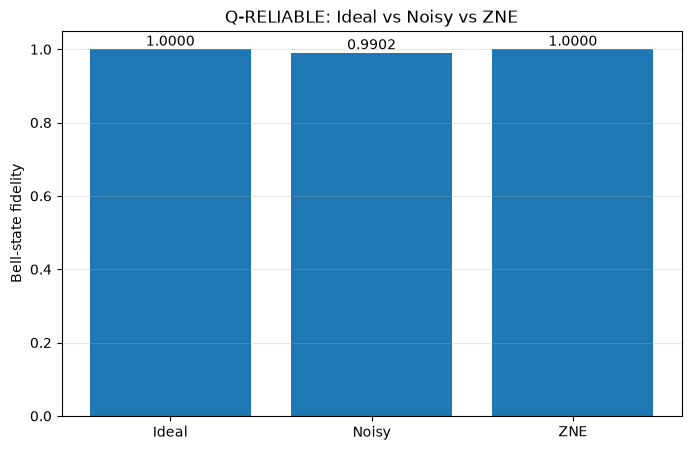

In [25]:
# Import Matplotlib for the final project visualization.
import matplotlib.pyplot as plt

# Define the three results we want to compare.
# Ideal = theoretical/reference result.
# Noisy = result before mitigation.
# ZNE = physically bounded mitigation result.
result_labels = [
    "Ideal",
    "Noisy",
    "ZNE"
]

result_fidelities = [
    ideal_fidelity,
    noisy_fidelity,
    bounded_zne_fidelity
]

# Create the figure.
plt.figure(figsize=(8, 5))

# Create a bar chart comparing the three fidelities.
plt.bar(
    result_labels,
    result_fidelities
)

# Label the y-axis.
plt.ylabel("Bell-state fidelity")

# Add a descriptive title.
plt.title("Q-RELIABLE: Ideal vs Noisy vs ZNE")

# Fidelity has a natural range from 0 to 1.
plt.ylim(0, 1.05)

# Add the numerical value above each bar.
for i, value in enumerate(result_fidelities):
    plt.text(
        i,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

# Add a light grid along the y-axis for readability.
plt.grid(
    axis="y",
    alpha=0.3
)

# Display the graph.
plt.show()

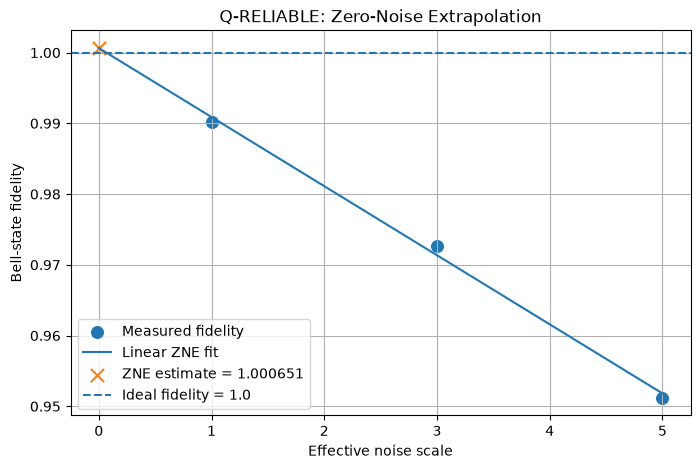

In [26]:
# Import Matplotlib for the ZNE extrapolation visualization.
import matplotlib.pyplot as plt
import numpy as np

# Experimental noise scales that we actually simulated.
measured_scales = np.array([1, 3, 5])

# Experimental fidelity values obtained from the noisy simulations.
measured_fidelities = np.array([
    noisy_fidelity,
    folded_fidelity,
    folded_5x_fidelity
])

# Create several x-values between 0 and 5.
# These are used only to draw the fitted ZNE line smoothly.
fit_scales = np.linspace(0, 5, 100)

# Calculate the predicted fidelity for each x-value
# using our fitted linear model:
#
# F(s) = intercept + slope * s
fit_fidelities = intercept + slope * fit_scales

# Create the figure.
plt.figure(figsize=(8, 5))

# Plot the experimentally measured points.
plt.scatter(
    measured_scales,
    measured_fidelities,
    s=70,
    label="Measured fidelity"
)

# Plot the linear ZNE fit.
plt.plot(
    fit_scales,
    fit_fidelities,
    label="Linear ZNE fit"
)

# Mark the zero-noise extrapolated point.
plt.scatter(
    [0],
    [zne_fidelity],
    s=90,
    marker="x",
    label=f"ZNE estimate = {zne_fidelity:.6f}"
)

# Mark the ideal reference fidelity.
plt.axhline(
    ideal_fidelity,
    linestyle="--",
    label="Ideal fidelity = 1.0"
)

# Label the axes.
plt.xlabel("Effective noise scale")
plt.ylabel("Bell-state fidelity")

# Add a descriptive title.
plt.title("Q-RELIABLE: Zero-Noise Extrapolation")

# Add a grid to make the values easier to interpret.
plt.grid(True)

# Display the legend.
plt.legend()

# Display the graph.
plt.show()

In [27]:
# ---------------------------------------------------------
# Q-RELIABLE: CIRCUIT CHARACTERIZATION
# ---------------------------------------------------------

# Number of qubits used by the circuit.
num_qubits = bell.num_qubits

# Circuit depth represents the longest sequence of
# operations that must be executed sequentially.
circuit_depth = bell.depth()

# count_ops() returns a dictionary containing the number
# of times each type of operation appears in the circuit.
operation_counts = bell.count_ops()

# Calculate the total number of operations.
total_gates = sum(operation_counts.values())

# Count the number of two-qubit CX gates.
# CX is the main noisy gate in our current noise model.
two_qubit_gates = operation_counts.get("cx", 0)

# Display the circuit characteristics.
print("----- Q-RELIABLE Circuit Characterization -----")
print("Number of qubits:", num_qubits)
print("Circuit depth:", circuit_depth)
print("Total operations:", total_gates)
print("Two-qubit CX gates:", two_qubit_gates)
print("Operation counts:", operation_counts)

----- Q-RELIABLE Circuit Characterization -----
Number of qubits: 2
Circuit depth: 3
Total operations: 5
Two-qubit CX gates: 1
Operation counts: OrderedDict([('measure', 2), ('h', 1), ('cx', 1), ('barrier', 1)])


In [28]:
# ---------------------------------------------------------
# Q-RELIABLE: NOISE-SCALE CIRCUIT CHARACTERIZATION
# ---------------------------------------------------------

# Create a list containing the three circuits used in
# our noise-scaling experiment.
scale_circuits = [
    ("1x", bell),
    ("3x", folded_bell),
    ("5x", folded_5x_bell)
]

# Analyze each circuit one by one.
for scale_name, circuit in scale_circuits:

    # Count how many operations of each type appear.
    operation_counts = circuit.count_ops()

    # Get the number of qubits.
    num_qubits = circuit.num_qubits

    # Calculate the circuit depth.
    circuit_depth = circuit.depth()

    # Calculate the total number of operations.
    total_gates = sum(operation_counts.values())

    # Count CX gates specifically.
    cx_gates = operation_counts.get("cx", 0)

    # Display the characterization results.
    print(f"\n----- {scale_name} Circuit -----")
    print("Qubits:", num_qubits)
    print("Circuit depth:", circuit_depth)
    print("Total operations:", total_gates)
    print("CX gates:", cx_gates)
    print("Operation counts:", operation_counts)


----- 1x Circuit -----
Qubits: 2
Circuit depth: 3
Total operations: 5
CX gates: 1
Operation counts: OrderedDict([('measure', 2), ('h', 1), ('cx', 1), ('barrier', 1)])

----- 3x Circuit -----
Qubits: 2
Circuit depth: 5
Total operations: 7
CX gates: 3
Operation counts: OrderedDict([('cx', 3), ('measure', 2), ('h', 1), ('barrier', 1)])

----- 5x Circuit -----
Qubits: 2
Circuit depth: 7
Total operations: 9
CX gates: 5
Operation counts: OrderedDict([('cx', 5), ('measure', 2), ('h', 1), ('barrier', 1)])


In [29]:
# ---------------------------------------------------------
# Q-RELIABLE: EMPIRICAL NOISE SENSITIVITY
# ---------------------------------------------------------

# Fidelity values measured at each noise scale.
fidelity_1x = noisy_fidelity
fidelity_3x = folded_fidelity
fidelity_5x = folded_5x_fidelity

# Number of CX gates at each scale.
cx_1x = 1
cx_3x = 3
cx_5x = 5

# Calculate fidelity loss between the 1x and 5x experiments.
fidelity_loss = fidelity_1x - fidelity_5x

# Calculate how many additional CX gates were introduced.
additional_cx_gates = cx_5x - cx_1x

# Calculate empirical fidelity loss per additional CX gate.
noise_sensitivity = (
    fidelity_loss / additional_cx_gates
)

# Display the results.
print("----- Q-RELIABLE Noise Sensitivity -----")
print("1x fidelity:", fidelity_1x)
print("5x fidelity:", fidelity_5x)
print("Fidelity loss:", fidelity_loss)
print("Additional CX gates:", additional_cx_gates)
print(
    "Empirical fidelity loss per additional CX:",
    noise_sensitivity
)

----- Q-RELIABLE Noise Sensitivity -----
1x fidelity: 0.990234375
5x fidelity: 0.951171875
Fidelity loss: 0.0390625
Additional CX gates: 4
Empirical fidelity loss per additional CX: 0.009765625


In [30]:
# ---------------------------------------------------------
# Q-RELIABLE: AUTOMATED RELIABILITY REPORT
# ---------------------------------------------------------

# Create a dictionary containing the main experimental
# and circuit-characterization results.
#
# A dictionary is useful because it stores related
# information together using meaningful names.
reliability_report = {

    # -------------------------------
    # Circuit characteristics
    # -------------------------------

    "qubits": bell.num_qubits,

    "original_depth": bell.depth(),

    "original_cx_gates": bell.count_ops().get("cx", 0),

    # -------------------------------
    # Noise configuration
    # -------------------------------

    "noise_probability": NOISE_PROBABILITY,

    # -------------------------------
    # Reliability measurements
    # -------------------------------

    "ideal_fidelity": ideal_fidelity,

    "noisy_fidelity": noisy_fidelity,

    "fidelity_at_3x": folded_fidelity,

    "fidelity_at_5x": folded_5x_fidelity,

    # -------------------------------
    # Noise sensitivity
    # -------------------------------

    "empirical_noise_sensitivity": noise_sensitivity,

    # -------------------------------
    # ZNE results
    # -------------------------------

    "raw_zne_estimate": zne_fidelity,

    "bounded_zne_fidelity": bounded_zne_fidelity,

    "relative_improvement_percent": relative_improvement,

    # -------------------------------
    # Remaining error
    # -------------------------------

    "remaining_error": remaining_error
}


# Display the complete reliability report.
print("==============================================")
print("          Q-RELIABLE REPORT")
print("==============================================")

print("\nCircuit Characteristics")
print("-----------------------")
print("Qubits:", reliability_report["qubits"])
print("Original depth:", reliability_report["original_depth"])
print("Original CX gates:", reliability_report["original_cx_gates"])

print("\nNoise Configuration")
print("-------------------")
print(
    "CX depolarizing probability:",
    reliability_report["noise_probability"]
)

print("\nMeasured Reliability")
print("--------------------")
print(
    "Ideal fidelity:",
    reliability_report["ideal_fidelity"]
)

print(
    "Noisy fidelity:",
    reliability_report["noisy_fidelity"]
)

print(
    "3x fidelity:",
    reliability_report["fidelity_at_3x"]
)

print(
    "5x fidelity:",
    reliability_report["fidelity_at_5x"]
)

print("\nNoise Sensitivity")
print("-----------------")
print(
    "Fidelity loss per additional CX:",
    reliability_report["empirical_noise_sensitivity"]
)

print("\nZNE Results")
print("-----------")
print(
    "Raw ZNE estimate:",
    reliability_report["raw_zne_estimate"]
)

print(
    "Bounded ZNE fidelity:",
    reliability_report["bounded_zne_fidelity"]
)

print(
    "Relative improvement (%):",
    reliability_report["relative_improvement_percent"]
)

print("\nRemaining Error")
print("---------------")
print(
    "Remaining error from ideal:",
    reliability_report["remaining_error"]
)

print("==============================================")

          Q-RELIABLE REPORT

Circuit Characteristics
-----------------------
Qubits: 2
Original depth: 3
Original CX gates: 1

Noise Configuration
-------------------
CX depolarizing probability: 0.02

Measured Reliability
--------------------
Ideal fidelity: 1.0
Noisy fidelity: 0.990234375
3x fidelity: 0.97265625
5x fidelity: 0.951171875

Noise Sensitivity
-----------------
Fidelity loss per additional CX: 0.009765625

ZNE Results
-----------
Raw ZNE estimate: 1.0006510416666663
Bounded ZNE fidelity: 1.0
Relative improvement (%): 1.0519395134779377

Remaining Error
---------------
Remaining error from ideal: 0.0


In [31]:
from qiskit import QuantumCircuit

# Create a quantum circuit with 3 qubits.
ghz = QuantumCircuit(3)

# H (Hadamard) creates a superposition on qubit 0.
ghz.h(0)

# CX entangles qubit 1 with qubit 0.
ghz.cx(0, 1)

# CX further entangles qubit 2 with qubit 1.
ghz.cx(1, 2)

# Measure all three qubits.
ghz.measure_all()

# Display the circuit.
print(ghz)

        ┌───┐           ░ ┌─┐      
   q_0: ┤ H ├──■────────░─┤M├──────
        └───┘┌─┴─┐      ░ └╥┘┌─┐   
   q_1: ─────┤ X ├──■───░──╫─┤M├───
             └───┘┌─┴─┐ ░  ║ └╥┘┌─┐
   q_2: ──────────┤ X ├─░──╫──╫─┤M├
                  └───┘ ░  ║  ║ └╥┘
meas: 3/═══════════════════╩══╩══╩═
                           0  1  2 


In [32]:
# Run the GHZ circuit on an ideal simulator.
# This simulator does not include our artificial noise model.

ideal_ghz_circuit = transpile(
    ghz,
    ideal_simulator
)

# Execute the circuit 1024 times.
# seed_simulator=42 makes the random simulation reproducible.
ideal_ghz_result = ideal_simulator.run(
    ideal_ghz_circuit,
    shots=SHOTS,
    seed_simulator=42
).result()

# Get the measurement counts.
ideal_ghz_counts = ideal_ghz_result.get_counts()

# Display the results.
print("Ideal GHZ counts:")
print(ideal_ghz_counts)

Ideal GHZ counts:
{'111': 534, '000': 490}


In [33]:
# Calculate the GHZ task-level fidelity.
#
# For our GHZ state, the expected measurement outcomes
# are only |000> and |111>.
ghz_ideal_fidelity = (
    ideal_ghz_counts.get("000", 0) +
    ideal_ghz_counts.get("111", 0)
) / SHOTS

# Display the calculated fidelity.
print("GHZ ideal fidelity:", ghz_ideal_fidelity)

GHZ ideal fidelity: 1.0


In [34]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ Circuit Characterization
# ---------------------------------------------------------

# Number of qubits used by the circuit.
ghz_num_qubits = ghz.num_qubits

# Circuit depth tells us how many sequential layers
# of operations are required.
ghz_depth = ghz.depth()

# count_ops() returns how many times each operation appears.
ghz_operation_counts = ghz.count_ops()

# Count all operations, including measurements and barriers.
ghz_total_operations = sum(ghz_operation_counts.values())

# Count only CX gates because our current noise model
# applies depolarizing noise specifically to CX gates.
ghz_cx_gates = ghz_operation_counts.get("cx", 0)

# Display the characterization results.
print("----- Q-RELIABLE GHZ Characterization -----")
print("Number of qubits:", ghz_num_qubits)
print("Circuit depth:", ghz_depth)
print("Total operations:", ghz_total_operations)
print("Two-qubit CX gates:", ghz_cx_gates)
print("Operation counts:", ghz_operation_counts)

----- Q-RELIABLE GHZ Characterization -----
Number of qubits: 3
Circuit depth: 4
Total operations: 7
Two-qubit CX gates: 2
Operation counts: OrderedDict([('measure', 3), ('cx', 2), ('h', 1), ('barrier', 1)])


In [35]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ Noisy Simulation
# ---------------------------------------------------------

# Transpile the GHZ circuit for our noisy simulator.
# This converts the circuit into instructions understood
# by the simulator while preserving the intended operations.
noisy_ghz_circuit = transpile(
    ghz,
    noisy_simulator
)

# Execute the GHZ circuit under the same noise model
# used for the Bell-state experiment.
noisy_ghz_result = noisy_simulator.run(
    noisy_ghz_circuit,
    shots=SHOTS,
    seed_simulator=42
).result()

# Retrieve the measurement counts.
noisy_ghz_counts = noisy_ghz_result.get_counts()

# Display the noisy measurement distribution.
print("Noisy GHZ counts:")
print(noisy_ghz_counts)

Noisy GHZ counts:
{'111': 489, '000': 510, '001': 10, '100': 4, '010': 2, '110': 5, '011': 4}


In [36]:
# ---------------------------------------------------------
# Q-RELIABLE: Calculate Noisy GHZ Fidelity
# ---------------------------------------------------------

# Count the two valid GHZ outcomes.
# Any other measurement outcome is treated as an error
# for this task-level reliability metric.
ghz_correct_count = (
    noisy_ghz_counts.get("000", 0) +
    noisy_ghz_counts.get("111", 0)
)

# Convert the correct-shot count into a fidelity value.
ghz_noisy_fidelity = ghz_correct_count / SHOTS

# Calculate the fraction of incorrect measurements.
ghz_error_rate = 1 - ghz_noisy_fidelity

# Display the results.
print("----- Q-RELIABLE GHZ Reliability -----")
print("Correct GHZ outcomes:", ghz_correct_count)
print("Total shots:", SHOTS)
print("Noisy GHZ fidelity:", ghz_noisy_fidelity)
print("Incorrect measurement rate:", ghz_error_rate)

----- Q-RELIABLE GHZ Reliability -----
Correct GHZ outcomes: 999
Total shots: 1024
Noisy GHZ fidelity: 0.9755859375
Incorrect measurement rate: 0.0244140625


In [37]:
# ---------------------------------------------------------
# Q-RELIABLE: Bell vs GHZ Reliability Comparison
# ---------------------------------------------------------

# Bell noisy fidelity was calculated during Phase 1.
bell_fidelity = noisy_fidelity

# GHZ noisy fidelity was calculated in the current phase.
ghz_fidelity = ghz_noisy_fidelity

# Calculate how much lower the GHZ fidelity is than Bell.
fidelity_difference = bell_fidelity - ghz_fidelity

# Calculate the additional CX gates used by GHZ.
additional_cx_gates = ghz_cx_gates - two_qubit_gates

# Display the comparison.
print("----- Bell vs GHZ Reliability -----")
print("Bell noisy fidelity:", bell_fidelity)
print("GHZ noisy fidelity:", ghz_fidelity)
print("Fidelity difference:", fidelity_difference)
print("Bell CX gates:", two_qubit_gates)
print("GHZ CX gates:", ghz_cx_gates)
print("Additional GHZ CX gates:", additional_cx_gates)

----- Bell vs GHZ Reliability -----
Bell noisy fidelity: 0.990234375
GHZ noisy fidelity: 0.9755859375
Fidelity difference: 0.0146484375
Bell CX gates: 1
GHZ CX gates: 2
Additional GHZ CX gates: 1


In [38]:
# ---------------------------------------------------------
# Q-RELIABLE: Basic Reliability Score
# ---------------------------------------------------------

# Convert measured fidelity from a 0-1 value
# into an easy-to-understand 0-100 score.
bell_reliability_score = bell_fidelity * 100
ghz_reliability_score = ghz_fidelity * 100

# Display the scores.
print("----- Q-RELIABLE Reliability Scores -----")
print("Bell reliability score:", bell_reliability_score)
print("GHZ reliability score:", ghz_reliability_score)

----- Q-RELIABLE Reliability Scores -----
Bell reliability score: 99.0234375
GHZ reliability score: 97.55859375


In [39]:
# ---------------------------------------------------------
# Q-RELIABLE: Reliability Loss
# ---------------------------------------------------------

# Ideal fidelity is 1.0 for both circuits because
# the ideal simulations produced only valid outcomes.
bell_ideal = ideal_fidelity
ghz_ideal = ghz_ideal_fidelity

# Calculate the reliability lost because of noise.
bell_reliability_loss = bell_ideal - bell_fidelity
ghz_reliability_loss = ghz_ideal - ghz_fidelity

# Compare the observed losses.
loss_ratio = ghz_reliability_loss / bell_reliability_loss

# Display the results.
print("----- Q-RELIABLE Reliability Loss -----")
print("Bell reliability loss:", bell_reliability_loss)
print("GHZ reliability loss:", ghz_reliability_loss)
print("GHZ/Bell loss ratio:", loss_ratio)

----- Q-RELIABLE Reliability Loss -----
Bell reliability loss: 0.009765625
GHZ reliability loss: 0.0244140625
GHZ/Bell loss ratio: 2.5


In [40]:
from qiskit import QuantumCircuit

# ---------------------------------------------------------
# Q-RELIABLE: 3x GHZ Noise-Scaled Circuit
# ---------------------------------------------------------

# Create a fresh 3-qubit circuit.
ghz_3x = QuantumCircuit(3)

# Prepare the GHZ superposition.
ghz_3x.h(0)

# Original CX(0,1) folded to 3 executions.
# Because CX is self-inverse:
# CX × CX × CX = CX
ghz_3x.cx(0, 1)
ghz_3x.cx(0, 1)
ghz_3x.cx(0, 1)

# Original CX(1,2) folded to 3 executions.
ghz_3x.cx(1, 2)
ghz_3x.cx(1, 2)
ghz_3x.cx(1, 2)

# Measure all qubits.
ghz_3x.measure_all()

# Display the circuit.
print(ghz_3x)

        ┌───┐                               ░ ┌─┐      
   q_0: ┤ H ├──■────■────■──────────────────░─┤M├──────
        └───┘┌─┴─┐┌─┴─┐┌─┴─┐                ░ └╥┘┌─┐   
   q_1: ─────┤ X ├┤ X ├┤ X ├──■────■────■───░──╫─┤M├───
             └───┘└───┘└───┘┌─┴─┐┌─┴─┐┌─┴─┐ ░  ║ └╥┘┌─┐
   q_2: ────────────────────┤ X ├┤ X ├┤ X ├─░──╫──╫─┤M├
                            └───┘└───┘└───┘ ░  ║  ║ └╥┘
meas: 3/═══════════════════════════════════════╩══╩══╩═
                                               0  1  2 


In [41]:
# ---------------------------------------------------------
# Q-RELIABLE: Verify 3x GHZ Circuit
# ---------------------------------------------------------

# Transpile with optimization_level=0.
# This prevents the transpiler from removing or simplifying
# the repeated CX gates that we intentionally added.
ghz_3x_noisy_circuit = transpile(
    ghz_3x,
    noisy_simulator,
    optimization_level=0
)

# Count the operations after transpilation.
ghz_3x_ops = ghz_3x_noisy_circuit.count_ops()

# Count the CX gates specifically.
ghz_3x_cx_gates = ghz_3x_ops.get("cx", 0)

# Display the verification results.
print("----- 3x GHZ Verification -----")
print("CX gates after transpilation:", ghz_3x_cx_gates)
print("Circuit depth:", ghz_3x_noisy_circuit.depth())
print("Operation counts:", ghz_3x_ops)

----- 3x GHZ Verification -----
CX gates after transpilation: 6
Circuit depth: 10
Operation counts: OrderedDict([('cx', 6), ('measure', 3), ('rz', 2), ('sx', 1), ('barrier', 1)])


In [42]:
# ---------------------------------------------------------
# Q-RELIABLE: 3x GHZ Noisy Simulation
# ---------------------------------------------------------

# Run the 3x noise-scaled GHZ circuit.
# The circuit contains 6 CX gates, so it experiences
# greater CX noise exposure than the original 2-CX GHZ circuit.
ghz_3x_result = noisy_simulator.run(
    ghz_3x_noisy_circuit,
    shots=SHOTS,
    seed_simulator=42
).result()

# Retrieve the measurement counts.
ghz_3x_counts = ghz_3x_result.get_counts()

# Display the results.
print("3x GHZ counts:")
print(ghz_3x_counts)

3x GHZ counts:
{'111': 463, '000': 484, '010': 6, '110': 25, '001': 24, '100': 6, '011': 12, '101': 4}


In [43]:
# ---------------------------------------------------------
# Q-RELIABLE: 3x GHZ Fidelity
# ---------------------------------------------------------

# For the GHZ task, only 000 and 111 are correct outcomes.
ghz_3x_correct = (
    ghz_3x_counts.get("000", 0) +
    ghz_3x_counts.get("111", 0)
)

# Convert the correct-shot count into task-level fidelity.
ghz_3x_fidelity = ghz_3x_correct / SHOTS

# Calculate the incorrect measurement rate.
ghz_3x_error_rate = 1 - ghz_3x_fidelity

# Display the results.
print("----- 3x GHZ Reliability -----")
print("Correct GHZ outcomes:", ghz_3x_correct)
print("Total shots:", SHOTS)
print("3x GHZ fidelity:", ghz_3x_fidelity)
print("Incorrect measurement rate:", ghz_3x_error_rate)

----- 3x GHZ Reliability -----
Correct GHZ outcomes: 947
Total shots: 1024
3x GHZ fidelity: 0.9248046875
Incorrect measurement rate: 0.0751953125


In [44]:
from qiskit import QuantumCircuit

# ---------------------------------------------------------
# Q-RELIABLE: 5x GHZ Noise-Scaled Circuit
# ---------------------------------------------------------

# Create a fresh 3-qubit GHZ circuit.
ghz_5x = QuantumCircuit(3)

# Prepare the GHZ superposition.
ghz_5x.h(0)

# Repeat CX(0,1) five times.
# Since CX is self-inverse, CX^5 = CX.
for _ in range(5):
    ghz_5x.cx(0, 1)

# Repeat CX(1,2) five times.
# This gives another 5 CX gates.
for _ in range(5):
    ghz_5x.cx(1, 2)

# Measure all qubits.
ghz_5x.measure_all()

# Display the circuit.
print(ghz_5x)

        ┌───┐                                                   ░ ┌─┐      
   q_0: ┤ H ├──■────■────■────■────■────────────────────────────░─┤M├──────
        └───┘┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐                          ░ └╥┘┌─┐   
   q_1: ─────┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├──■────■────■────■────■───░──╫─┤M├───
             └───┘└───┘└───┘└───┘└───┘┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐┌─┴─┐ ░  ║ └╥┘┌─┐
   q_2: ──────────────────────────────┤ X ├┤ X ├┤ X ├┤ X ├┤ X ├─░──╫──╫─┤M├
                                      └───┘└───┘└───┘└───┘└───┘ ░  ║  ║ └╥┘
meas: 3/═══════════════════════════════════════════════════════════╩══╩══╩═
                                                                   0  1  2 


In [45]:
# ---------------------------------------------------------
# Q-RELIABLE: Verify 5x GHZ Circuit
# ---------------------------------------------------------

# Use optimization_level=0 so Qiskit does not simplify
# our intentionally repeated CX gates.
ghz_5x_noisy_circuit = transpile(
    ghz_5x,
    noisy_simulator,
    optimization_level=0
)

# Count all operations after transpilation.
ghz_5x_ops = ghz_5x_noisy_circuit.count_ops()

# Count the CX gates specifically.
ghz_5x_cx_gates = ghz_5x_ops.get("cx", 0)

# Display the verification results.
print("----- 5x GHZ Verification -----")
print("CX gates after transpilation:", ghz_5x_cx_gates)
print("Circuit depth:", ghz_5x_noisy_circuit.depth())
print("Operation counts:", ghz_5x_ops)

----- 5x GHZ Verification -----
CX gates after transpilation: 10
Circuit depth: 14
Operation counts: OrderedDict([('cx', 10), ('measure', 3), ('rz', 2), ('sx', 1), ('barrier', 1)])


In [46]:
# ---------------------------------------------------------
# Q-RELIABLE: 5x GHZ Noisy Simulation
# ---------------------------------------------------------

# Execute the 5x noise-scaled GHZ circuit.
# It contains 10 CX gates, so it has substantially more
# exposure to the CX depolarizing noise model.
ghz_5x_result = noisy_simulator.run(
    ghz_5x_noisy_circuit,
    shots=SHOTS,
    seed_simulator=42
).result()

# Retrieve the measurement counts.
ghz_5x_counts = ghz_5x_result.get_counts()

# Display the measurement distribution.
print("5x GHZ counts:")
print(ghz_5x_counts)

5x GHZ counts:
{'111': 439, '000': 448, '011': 16, '110': 36, '101': 14, '010': 11, '001': 51, '100': 9}


In [47]:
# ---------------------------------------------------------
# Q-RELIABLE: 5x GHZ Fidelity
# ---------------------------------------------------------

# For the GHZ task, only 000 and 111 are correct outcomes.
ghz_5x_correct = (
    ghz_5x_counts.get("000", 0) +
    ghz_5x_counts.get("111", 0)
)

# Convert the correct-shot count into task-level fidelity.
ghz_5x_fidelity = ghz_5x_correct / SHOTS

# Calculate the incorrect measurement rate.
ghz_5x_error_rate = 1 - ghz_5x_fidelity

# Display the results.
print("----- 5x GHZ Reliability -----")
print("Correct GHZ outcomes:", ghz_5x_correct)
print("Total shots:", SHOTS)
print("5x GHZ fidelity:", ghz_5x_fidelity)
print("Incorrect measurement rate:", ghz_5x_error_rate)

----- 5x GHZ Reliability -----
Correct GHZ outcomes: 887
Total shots: 1024
5x GHZ fidelity: 0.8662109375
Incorrect measurement rate: 0.1337890625


In [48]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ Noise Sensitivity
# ---------------------------------------------------------

# Fidelity at the original GHZ circuit.
ghz_fidelity_1x = ghz_noisy_fidelity

# Fidelity after 5x noise scaling.
ghz_fidelity_5x = ghz_5x_fidelity

# Original GHZ contains 2 CX gates.
ghz_cx_1x = 2

# 5x GHZ contains 10 CX gates.
ghz_cx_5x = 10

# Total fidelity loss between the original and 5x circuit.
ghz_fidelity_loss = (
    ghz_fidelity_1x - ghz_fidelity_5x
)

# Additional noisy CX operations introduced by scaling.
ghz_additional_cx = (
    ghz_cx_5x - ghz_cx_1x
)

# Empirical fidelity loss per additional CX.
# This is a project-level experimental metric,
# NOT a universal physical CX error rate.
ghz_noise_sensitivity = (
    ghz_fidelity_loss / ghz_additional_cx
)

# Display the results.
print("----- Q-RELIABLE GHZ Noise Sensitivity -----")
print("1x GHZ fidelity:", ghz_fidelity_1x)
print("5x GHZ fidelity:", ghz_fidelity_5x)
print("Fidelity loss:", ghz_fidelity_loss)
print("Additional CX gates:", ghz_additional_cx)
print(
    "Empirical fidelity loss per additional CX:",
    ghz_noise_sensitivity
)

----- Q-RELIABLE GHZ Noise Sensitivity -----
1x GHZ fidelity: 0.9755859375
5x GHZ fidelity: 0.8662109375
Fidelity loss: 0.109375
Additional CX gates: 8
Empirical fidelity loss per additional CX: 0.013671875


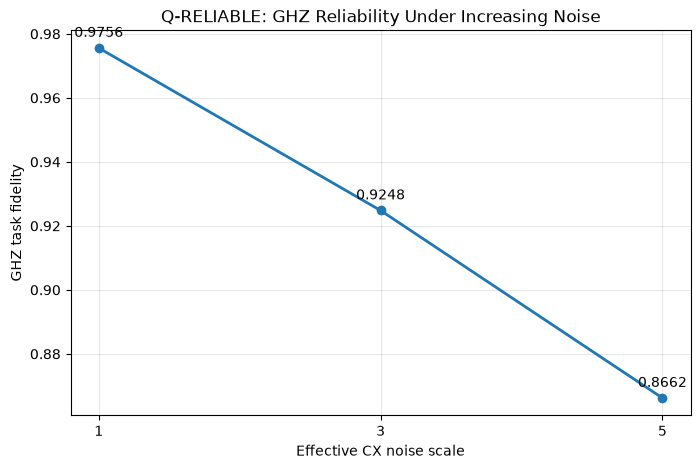

In [49]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Q-RELIABLE: GHZ Noise Sensitivity Graph
# ---------------------------------------------------------

# Effective noise scales used in the experiment.
ghz_scales = [1, 3, 5]

# Corresponding number of CX gates.
ghz_cx_counts = [2, 6, 10]

# Measured GHZ fidelities.
ghz_fidelities = [
    ghz_fidelity_1x,
    ghz_3x_fidelity,
    ghz_5x_fidelity
]

# Create the plot.
plt.figure(figsize=(8, 5))

# Plot fidelity against effective noise scale.
plt.plot(
    ghz_scales,
    ghz_fidelities,
    marker="o",
    linewidth=2
)

# Label each measured point.
for scale, fidelity in zip(ghz_scales, ghz_fidelities):
    plt.annotate(
        f"{fidelity:.4f}",
        (scale, fidelity),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

# Add axis labels and title.
plt.xlabel("Effective CX noise scale")
plt.ylabel("GHZ task fidelity")
plt.title("Q-RELIABLE: GHZ Reliability Under Increasing Noise")

# Show the three experimental points clearly.
plt.xticks(ghz_scales)

# Add a light grid to make values easier to read.
plt.grid(True, alpha=0.3)

plt.show()

In [50]:
# ---------------------------------------------------------
# Q-RELIABLE: Automatic Mitigation Decision
# ---------------------------------------------------------

# Prototype threshold for deciding whether mitigation
# should be investigated.
#
# IMPORTANT:
# This is a configurable demonstration threshold,
# NOT a universal quantum-hardware standard.
RELIABILITY_THRESHOLD = 0.95

# Function that decides whether mitigation should be applied.
def decide_mitigation(fidelity, threshold=RELIABILITY_THRESHOLD):
    """
    Decide whether a circuit should undergo mitigation.

    Parameters:
        fidelity : measured task-level fidelity (0 to 1)
        threshold : configurable reliability threshold

    Returns:
        "MITIGATE" if fidelity is below the threshold.
        "NO_MITIGATION" otherwise.
    """

    if fidelity < threshold:
        return "MITIGATE"
    else:
        return "NO_MITIGATION"


# Test the decision system on our two original circuits.
bell_decision = decide_mitigation(bell_fidelity)
ghz_decision = decide_mitigation(ghz_fidelity)

# Display the decisions.
print("----- Q-RELIABLE Mitigation Decision -----")
print("Reliability threshold:", RELIABILITY_THRESHOLD)
print("Bell fidelity:", bell_fidelity)
print("Bell decision:", bell_decision)
print()
print("GHZ fidelity:", ghz_fidelity)
print("GHZ decision:", ghz_decision)

----- Q-RELIABLE Mitigation Decision -----
Reliability threshold: 0.95
Bell fidelity: 0.990234375
Bell decision: NO_MITIGATION

GHZ fidelity: 0.9755859375
GHZ decision: NO_MITIGATION


In [51]:
# ---------------------------------------------------------
# Q-RELIABLE: Test Mitigation Decisions Across Noise Levels
# ---------------------------------------------------------

# Store the GHZ experimental fidelities together with
# their corresponding noise scales.
ghz_experiment = [
    ("1x", ghz_fidelity_1x),
    ("3x", ghz_3x_fidelity),
    ("5x", ghz_5x_fidelity)
]

print("----- Q-RELIABLE GHZ Mitigation Decisions -----")
print("Reliability threshold:", RELIABILITY_THRESHOLD)
print()

# Evaluate every experimental condition.
for scale, fidelity in ghz_experiment:

    # Ask the Q-RELIABLE decision function whether
    # mitigation should be investigated.
    decision = decide_mitigation(fidelity)

    print(
        scale,
        "| Fidelity:",
        round(fidelity, 4),
        "| Decision:",
        decision
    )

----- Q-RELIABLE GHZ Mitigation Decisions -----
Reliability threshold: 0.95

1x | Fidelity: 0.9756 | Decision: NO_MITIGATION
3x | Fidelity: 0.9248 | Decision: MITIGATE
5x | Fidelity: 0.8662 | Decision: MITIGATE


In [52]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ Zero-Noise Extrapolation
# ---------------------------------------------------------

import numpy as np

# Noise scales used in our GHZ experiment.
# 1x = original circuit
# 3x = 3-fold CX noise exposure
# 5x = 5-fold CX noise exposure
ghz_noise_scales = np.array([1, 3, 5])

# Measured GHZ task-level fidelities at each noise scale.
ghz_fidelities = np.array([
    ghz_fidelity_1x,
    ghz_3x_fidelity,
    ghz_5x_fidelity
])

# Fit a straight line:
#
# fidelity = slope * noise_scale + intercept
#
# At noise_scale = 0, the intercept represents our
# estimated zero-noise fidelity.
ghz_slope, ghz_intercept = np.polyfit(
    ghz_noise_scales,
    ghz_fidelities,
    1
)

# The intercept is the raw ZNE estimate.
ghz_zne_fidelity = ghz_intercept

# Physical fidelity must lie between 0 and 1.
# We keep the raw value for transparency, but also create
# a bounded value for physical reporting.
ghz_bounded_zne_fidelity = min(
    max(ghz_zne_fidelity, 0.0),
    1.0
)

print("----- Q-RELIABLE GHZ ZNE -----")
print("ZNE slope:", ghz_slope)
print("Raw ZNE estimate:", ghz_zne_fidelity)
print("Bounded ZNE fidelity:", ghz_bounded_zne_fidelity)

----- Q-RELIABLE GHZ ZNE -----
ZNE slope: -0.02734374999999999
Raw ZNE estimate: 1.0042317708333328
Bounded ZNE fidelity: 1.0


In [53]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ Mitigation Metrics
# ---------------------------------------------------------

# The original 1x GHZ fidelity represents the noisy result
# before applying zero-noise extrapolation.
ghz_original_fidelity = ghz_fidelity_1x

# Calculate the improvement using the RAW ZNE estimate.
# This is kept for transparency because the extrapolation
# itself produced a value slightly above the physical range.
ghz_raw_mitigation_gain = (
    ghz_zne_fidelity - ghz_original_fidelity
)

# Calculate relative improvement as a percentage.
ghz_relative_improvement = (
    ghz_raw_mitigation_gain /
    ghz_original_fidelity
) * 100

# Calculate improvement using the physically bounded
# ZNE fidelity. This is the value we use for physical
# reliability reporting.
ghz_bounded_mitigation_gain = (
    ghz_bounded_zne_fidelity -
    ghz_original_fidelity
)

# Calculate the remaining error relative to the ideal
# GHZ fidelity.
ghz_remaining_error = (
    ghz_ideal_fidelity -
    ghz_bounded_zne_fidelity
)

print("----- Q-RELIABLE GHZ Mitigation Results -----")
print("Original noisy fidelity:", ghz_original_fidelity)
print("Raw ZNE estimate:", ghz_zne_fidelity)
print("Raw mitigation gain:", ghz_raw_mitigation_gain)
print("Relative improvement (%):", ghz_relative_improvement)
print("Bounded ZNE fidelity:", ghz_bounded_zne_fidelity)
print("Bounded mitigation gain:", ghz_bounded_mitigation_gain)
print("Remaining error from ideal:", ghz_remaining_error)

----- Q-RELIABLE GHZ Mitigation Results -----
Original noisy fidelity: 0.9755859375
Raw ZNE estimate: 1.0042317708333328
Raw mitigation gain: 0.028645833333332815
Relative improvement (%): 2.9362696029362167
Bounded ZNE fidelity: 1.0
Bounded mitigation gain: 0.0244140625
Remaining error from ideal: 0.0


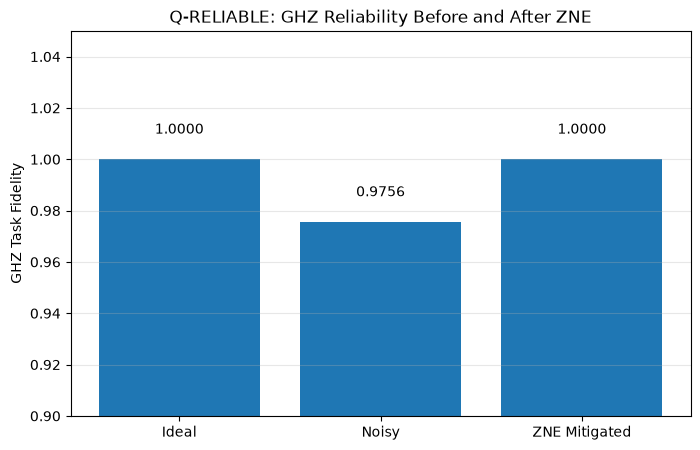

In [54]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ Mitigation Comparison
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Define the three reliability values we want to compare.
ghz_comparison_labels = [
    "Ideal",
    "Noisy",
    "ZNE Mitigated"
]

ghz_comparison_values = [
    ghz_ideal_fidelity,
    ghz_original_fidelity,
    ghz_bounded_zne_fidelity
]

# Create the bar chart.
plt.figure(figsize=(8, 5))

bars = plt.bar(
    ghz_comparison_labels,
    ghz_comparison_values
)

# Add the numerical fidelity value above each bar.
for bar, value in zip(bars, ghz_comparison_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

# Label the axes and graph.
plt.ylabel("GHZ Task Fidelity")
plt.ylim(0.90, 1.05)
plt.title("Q-RELIABLE: GHZ Reliability Before and After ZNE")

# Add a light grid to make comparison easier.
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [55]:
# ---------------------------------------------------------
# Q-RELIABLE: Recalculate GHZ Circuit Characteristics
# ---------------------------------------------------------

# Number of qubits in the GHZ circuit.
ghz_num_qubits = ghz.num_qubits

# Calculate the circuit depth.
ghz_circuit_depth = ghz.depth()

# Count all operations in the circuit.
ghz_operation_counts = ghz.count_ops()

# Count the two-qubit CX gates specifically.
ghz_two_qubit_gates = ghz_operation_counts.get("cx", 0)

# Count all operations for reporting purposes.
ghz_total_operations = sum(
    ghz_operation_counts.values()
)

print("----- Q-RELIABLE GHZ Characterization -----")
print("Number of qubits:", ghz_num_qubits)
print("Circuit depth:", ghz_circuit_depth)
print("Total operations:", ghz_total_operations)
print("Two-qubit CX gates:", ghz_two_qubit_gates)
print("Operation counts:", ghz_operation_counts)

----- Q-RELIABLE GHZ Characterization -----
Number of qubits: 3
Circuit depth: 4
Total operations: 7
Two-qubit CX gates: 2
Operation counts: OrderedDict([('measure', 3), ('cx', 2), ('h', 1), ('barrier', 1)])


In [56]:
# ---------------------------------------------------------
# Q-RELIABLE: Circuit Reliability Summary
# ---------------------------------------------------------

# Store the key engineering metrics for the Bell circuit.
bell_summary = {
    "Circuit": "Bell",
    "Qubits": num_qubits,
    "CX Gates": two_qubit_gates,
    "Depth": circuit_depth,
    "Noisy Fidelity": noisy_fidelity,
    "Decision": bell_decision
}

# Store the key engineering metrics for the GHZ circuit.
ghz_summary = {
    "Circuit": "GHZ",
    "Qubits": ghz_num_qubits,
    "CX Gates": ghz_two_qubit_gates,
    "Depth": ghz_circuit_depth,
    "Noisy Fidelity": ghz_fidelity,
    "Decision": ghz_decision
}

print("----- Q-RELIABLE Circuit Reliability Summary -----")
print()

# Display Bell circuit results.
print("Circuit:", bell_summary["Circuit"])
print("Qubits:", bell_summary["Qubits"])
print("CX gates:", bell_summary["CX Gates"])
print("Depth:", bell_summary["Depth"])
print("Noisy fidelity:", round(bell_summary["Noisy Fidelity"], 4))
print("Mitigation decision:", bell_summary["Decision"])

print()

# Display GHZ circuit results.
print("Circuit:", ghz_summary["Circuit"])
print("Qubits:", ghz_summary["Qubits"])
print("CX gates:", ghz_summary["CX Gates"])
print("Depth:", ghz_summary["Depth"])
print("Noisy fidelity:", round(ghz_summary["Noisy Fidelity"], 4))
print("Mitigation decision:", ghz_summary["Decision"])

----- Q-RELIABLE Circuit Reliability Summary -----

Circuit: Bell
Qubits: 2
CX gates: 1
Depth: 7
Noisy fidelity: 0.9902
Mitigation decision: NO_MITIGATION

Circuit: GHZ
Qubits: 3
CX gates: 2
Depth: 4
Noisy fidelity: 0.9756
Mitigation decision: NO_MITIGATION


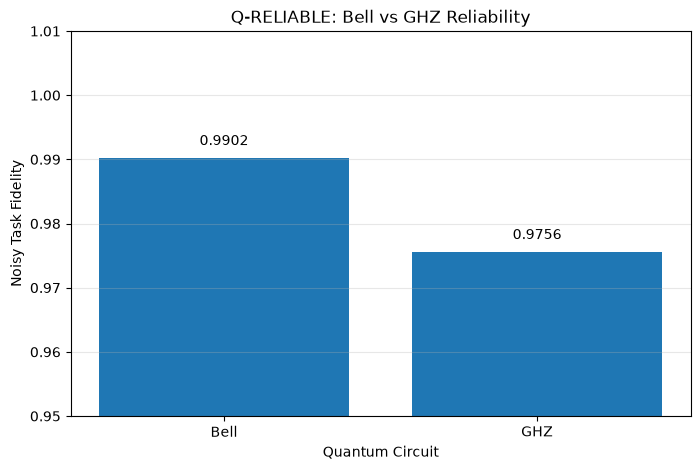

In [57]:
# ---------------------------------------------------------
# Q-RELIABLE: Bell vs GHZ Reliability Comparison
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Names of the circuits being compared.
circuit_names = [
    "Bell",
    "GHZ"
]

# Measured noisy fidelities for each circuit.
circuit_fidelities = [
    bell_summary["Noisy Fidelity"],
    ghz_summary["Noisy Fidelity"]
]

# Create the comparison bar chart.
plt.figure(figsize=(8, 5))

bars = plt.bar(
    circuit_names,
    circuit_fidelities
)

# Display the exact fidelity value above each bar.
for bar, fidelity in zip(bars, circuit_fidelities):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        fidelity + 0.002,
        f"{fidelity:.4f}",
        ha="center"
    )

# Label the graph.
plt.xlabel("Quantum Circuit")
plt.ylabel("Noisy Task Fidelity")
plt.title("Q-RELIABLE: Bell vs GHZ Reliability")

# Keep the graph focused on the relevant fidelity range.
plt.ylim(0.95, 1.01)

# Add a horizontal grid to make the values easier to compare.
plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

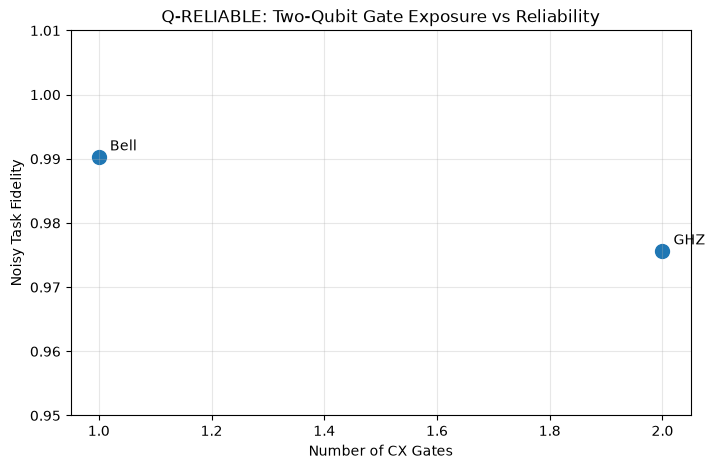

In [58]:
# ---------------------------------------------------------
# Q-RELIABLE: Circuit Complexity vs Reliability
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Number of CX gates in each circuit.
cx_gate_counts = [
    bell_summary["CX Gates"],
    ghz_summary["CX Gates"]
]

# Corresponding noisy task-level fidelities.
reliability_values = [
    bell_summary["Noisy Fidelity"],
    ghz_summary["Noisy Fidelity"]
]

# Circuit names used as labels on the graph.
circuit_labels = [
    "Bell",
    "GHZ"
]

# Create the scatter plot.
plt.figure(figsize=(8, 5))

plt.scatter(
    cx_gate_counts,
    reliability_values,
    s=100
)

# Label each point with its circuit name.
for cx_count, reliability, label in zip(
    cx_gate_counts,
    reliability_values,
    circuit_labels
):
    plt.annotate(
        label,
        (cx_count, reliability),
        xytext=(8, 5),
        textcoords="offset points"
    )

# Label the axes.
plt.xlabel("Number of CX Gates")
plt.ylabel("Noisy Task Fidelity")

# Give the graph a descriptive title.
plt.title(
    "Q-RELIABLE: Two-Qubit Gate Exposure vs Reliability"
)

# Set a focused reliability range.
plt.ylim(0.95, 1.01)

# Add a grid for easier interpretation.
plt.grid(
    True,
    alpha=0.3
)

plt.show()

In [59]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ-4 Circuit
# ---------------------------------------------------------

from qiskit import QuantumCircuit

# Create a 4-qubit quantum circuit.
ghz4 = QuantumCircuit(4)

# Put qubit 0 into superposition.
ghz4.h(0)

# Create a chain of entanglement.
# Each CX connects one qubit to the next.
ghz4.cx(0, 1)
ghz4.cx(1, 2)
ghz4.cx(2, 3)

# Measure all four qubits.
ghz4.measure_all()

# Display the circuit for verification.
print(ghz4)

        ┌───┐                ░ ┌─┐         
   q_0: ┤ H ├──■─────────────░─┤M├─────────
        └───┘┌─┴─┐           ░ └╥┘┌─┐      
   q_1: ─────┤ X ├──■────────░──╫─┤M├──────
             └───┘┌─┴─┐      ░  ║ └╥┘┌─┐   
   q_2: ──────────┤ X ├──■───░──╫──╫─┤M├───
                  └───┘┌─┴─┐ ░  ║  ║ └╥┘┌─┐
   q_3: ───────────────┤ X ├─░──╫──╫──╫─┤M├
                       └───┘ ░  ║  ║  ║ └╥┘
meas: 4/════════════════════════╩══╩══╩══╩═
                                0  1  2  3 


In [60]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ-4 Ideal Simulation
# ---------------------------------------------------------

from qiskit import transpile

# Use the ideal simulator that we already created earlier.
# No noise model is attached here.
ghz4_ideal_simulator = AerSimulator()

# Transpile the GHZ-4 circuit for the simulator.
ghz4_ideal_circuit = transpile(
    ghz4,
    ghz4_ideal_simulator
)

# Run the ideal circuit using the same 1024-shot setting
# used throughout our experiments.
ghz4_ideal_result = ghz4_ideal_simulator.run(
    ghz4_ideal_circuit,
    shots=SHOTS,
    seed_simulator=42
).result()

# Extract the measurement counts.
ghz4_ideal_counts = ghz4_ideal_result.get_counts()

# Calculate GHZ-4 task-level fidelity.
# Only 0000 and 1111 are considered correct outcomes.
ghz4_ideal_fidelity = (
    ghz4_ideal_counts.get("0000", 0) +
    ghz4_ideal_counts.get("1111", 0)
) / SHOTS

print("----- Q-RELIABLE GHZ-4 Ideal Simulation -----")
print("Ideal counts:", ghz4_ideal_counts)
print("Ideal GHZ-4 fidelity:", ghz4_ideal_fidelity)

----- Q-RELIABLE GHZ-4 Ideal Simulation -----
Ideal counts: {'0000': 506, '1111': 518}
Ideal GHZ-4 fidelity: 1.0


In [61]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ-4 Noisy Simulation
# ---------------------------------------------------------

# Create an Aer simulator using the same noise model
# used for our Bell and GHZ-3 experiments.
ghz4_noisy_simulator = AerSimulator(
    noise_model=noise_model
)

# Transpile the GHZ-4 circuit for the noisy simulator.
ghz4_noisy_circuit = transpile(
    ghz4,
    ghz4_noisy_simulator
)

# Run the noisy GHZ-4 experiment.
ghz4_noisy_result = ghz4_noisy_simulator.run(
    ghz4_noisy_circuit,
    shots=SHOTS,
    seed_simulator=42
).result()

# Extract the measurement counts.
ghz4_noisy_counts = ghz4_noisy_result.get_counts()

# Calculate task-level GHZ-4 fidelity.
# Only 0000 and 1111 are considered correct GHZ outcomes.
ghz4_noisy_fidelity = (
    ghz4_noisy_counts.get("0000", 0) +
    ghz4_noisy_counts.get("1111", 0)
) / SHOTS

# Calculate the fraction of incorrect measurement outcomes.
ghz4_error_rate = 1 - ghz4_noisy_fidelity

print("----- Q-RELIABLE GHZ-4 Noisy Simulation -----")
print("Noisy counts:", ghz4_noisy_counts)
print("Noisy GHZ-4 fidelity:", ghz4_noisy_fidelity)
print("Incorrect measurement rate:", ghz4_error_rate)

----- Q-RELIABLE GHZ-4 Noisy Simulation -----
Noisy counts: {'1111': 484, '1000': 4, '0000': 502, '1100': 3, '0011': 9, '1110': 5, '0100': 2, '0001': 8, '0111': 4, '1101': 2, '0010': 1}
Noisy GHZ-4 fidelity: 0.962890625
Incorrect measurement rate: 0.037109375


In [62]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ-5 Circuit
# ---------------------------------------------------------

from qiskit import QuantumCircuit

# Create a 5-qubit quantum circuit.
ghz5 = QuantumCircuit(5)

# Put the first qubit into superposition.
ghz5.h(0)

# Create a chain of entanglement across all 5 qubits.
# This requires four two-qubit CX operations.
ghz5.cx(0, 1)
ghz5.cx(1, 2)
ghz5.cx(2, 3)
ghz5.cx(3, 4)

# Measure all five qubits.
ghz5.measure_all()

# Display the circuit for verification.
print(ghz5)

        ┌───┐                     ░ ┌─┐            
   q_0: ┤ H ├──■──────────────────░─┤M├────────────
        └───┘┌─┴─┐                ░ └╥┘┌─┐         
   q_1: ─────┤ X ├──■─────────────░──╫─┤M├─────────
             └───┘┌─┴─┐           ░  ║ └╥┘┌─┐      
   q_2: ──────────┤ X ├──■────────░──╫──╫─┤M├──────
                  └───┘┌─┴─┐      ░  ║  ║ └╥┘┌─┐   
   q_3: ───────────────┤ X ├──■───░──╫──╫──╫─┤M├───
                       └───┘┌─┴─┐ ░  ║  ║  ║ └╥┘┌─┐
   q_4: ────────────────────┤ X ├─░──╫──╫──╫──╫─┤M├
                            └───┘ ░  ║  ║  ║  ║ └╥┘
meas: 5/═════════════════════════════╩══╩══╩══╩══╩═
                                     0  1  2  3  4 


In [63]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ-5 Ideal Simulation
# ---------------------------------------------------------

# Create a fresh ideal Aer simulator.
# No noise model is attached.
ghz5_ideal_simulator = AerSimulator()

# Transpile the GHZ-5 circuit for the ideal simulator.
ghz5_ideal_circuit = transpile(
    ghz5,
    ghz5_ideal_simulator
)

# Execute the circuit using the same 1024 shots and seed
# used throughout our controlled experiments.
ghz5_ideal_result = ghz5_ideal_simulator.run(
    ghz5_ideal_circuit,
    shots=SHOTS,
    seed_simulator=42
).result()

# Extract measurement counts from the ideal simulation.
ghz5_ideal_counts = ghz5_ideal_result.get_counts()

# Calculate GHZ-5 task-level fidelity.
# Only 00000 and 11111 are considered correct outcomes.
ghz5_ideal_fidelity = (
    ghz5_ideal_counts.get("00000", 0) +
    ghz5_ideal_counts.get("11111", 0)
) / SHOTS

print("----- Q-RELIABLE GHZ-5 Ideal Simulation -----")
print("Ideal counts:", ghz5_ideal_counts)
print("Ideal GHZ-5 fidelity:", ghz5_ideal_fidelity)

----- Q-RELIABLE GHZ-5 Ideal Simulation -----
Ideal counts: {'00000': 541, '11111': 483}
Ideal GHZ-5 fidelity: 1.0


In [64]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ-5 Noisy Simulation
# ---------------------------------------------------------

# Create an Aer simulator using the same noise model
# used for all previous experiments.
ghz5_noisy_simulator = AerSimulator(
    noise_model=noise_model
)

# Transpile the GHZ-5 circuit for the noisy simulator.
ghz5_noisy_circuit = transpile(
    ghz5,
    ghz5_noisy_simulator
)

# Execute GHZ-5 using the same number of shots and seed.
ghz5_noisy_result = ghz5_noisy_simulator.run(
    ghz5_noisy_circuit,
    shots=SHOTS,
    seed_simulator=42
).result()

# Extract measurement counts.
ghz5_noisy_counts = ghz5_noisy_result.get_counts()

# Calculate GHZ-5 task-level fidelity.
# Only 00000 and 11111 are considered correct outcomes.
ghz5_noisy_fidelity = (
    ghz5_noisy_counts.get("00000", 0) +
    ghz5_noisy_counts.get("11111", 0)
) / SHOTS

# Calculate the fraction of incorrect outcomes.
ghz5_error_rate = 1 - ghz5_noisy_fidelity

print("----- Q-RELIABLE GHZ-5 Noisy Simulation -----")
print("Noisy counts:", ghz5_noisy_counts)
print("Noisy GHZ-5 fidelity:", ghz5_noisy_fidelity)
print("Incorrect measurement rate:", ghz5_error_rate)

----- Q-RELIABLE GHZ-5 Noisy Simulation -----
Noisy counts: {'00111': 9, '11111': 470, '01000': 2, '00000': 494, '11110': 14, '11100': 4, '10000': 4, '00001': 8, '00011': 6, '11101': 1, '11000': 3, '01111': 4, '00010': 2, '11011': 2, '00100': 1}
Noisy GHZ-5 fidelity: 0.94140625
Incorrect measurement rate: 0.05859375


In [65]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ-5 Mitigation Decision
# ---------------------------------------------------------

# Use the existing Q-RELIABLE decision engine to determine
# whether GHZ-5 requires mitigation.
ghz5_decision = decide_mitigation(
    ghz5_noisy_fidelity
)

print("----- Q-RELIABLE GHZ-5 Mitigation Decision -----")
print("Reliability threshold:", RELIABILITY_THRESHOLD)
print("GHZ-5 noisy fidelity:", ghz5_noisy_fidelity)
print("GHZ-5 decision:", ghz5_decision)

----- Q-RELIABLE GHZ-5 Mitigation Decision -----
Reliability threshold: 0.95
GHZ-5 noisy fidelity: 0.94140625
GHZ-5 decision: MITIGATE


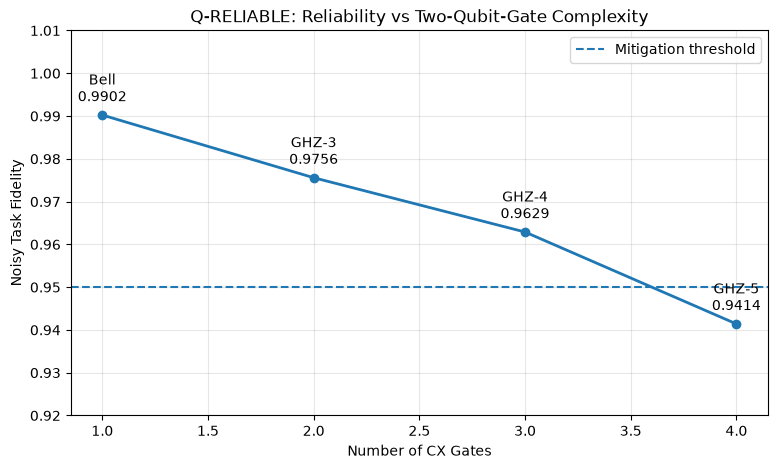

In [66]:
# ---------------------------------------------------------
# Q-RELIABLE: Reliability vs CX-Gate Complexity
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Number of CX gates for each tested circuit.
cx_gate_counts = [
    1,                      # Bell
    2,                      # GHZ-3
    ghz4_noisy_circuit.count_ops().get("cx", 0),
    ghz5_noisy_circuit.count_ops().get("cx", 0)
]

# Measured noisy task-level fidelities.
fidelity_values = [
    noisy_fidelity,          # Bell
    ghz_fidelity,            # GHZ-3
    ghz4_noisy_fidelity,     # GHZ-4
    ghz5_noisy_fidelity      # GHZ-5
]

# Labels for the individual circuits.
circuit_labels = [
    "Bell",
    "GHZ-3",
    "GHZ-4",
    "GHZ-5"
]

# Create the graph.
plt.figure(figsize=(9, 5))

plt.plot(
    cx_gate_counts,
    fidelity_values,
    marker="o",
    linewidth=2
)

# Add the circuit name and fidelity to every point.
for cx_count, fidelity, label in zip(
    cx_gate_counts,
    fidelity_values,
    circuit_labels
):
    plt.annotate(
        f"{label}\n{fidelity:.4f}",
        (cx_count, fidelity),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

# Draw the Q-RELIABLE mitigation threshold.
plt.axhline(
    y=RELIABILITY_THRESHOLD,
    linestyle="--",
    linewidth=1.5,
    label="Mitigation threshold"
)

# Label the axes.
plt.xlabel("Number of CX Gates")
plt.ylabel("Noisy Task Fidelity")

# Add a descriptive title.
plt.title(
    "Q-RELIABLE: Reliability vs Two-Qubit-Gate Complexity"
)

# Keep the graph focused on the observed reliability range.
plt.ylim(0.92, 1.01)

# Display the legend and grid.
plt.legend()
plt.grid(
    True,
    alpha=0.3
)

plt.show()

In [67]:
# ---------------------------------------------------------
# Q-RELIABLE: Classical Bell Reference
# ---------------------------------------------------------

import numpy as np

# Create a reproducible random-number generator.
# Using a fixed seed makes the experiment repeatable.
classical_rng = np.random.default_rng(42)

# Use the same number of samples/shots as the quantum
# experiments so the comparison is fair.
classical_bell_shots = SHOTS

# Generate random values between 0 and 1.
random_values = classical_rng.random(
    classical_bell_shots
)

# Construct the ideal Bell measurement distribution.
#
# If the random value is below 0.5, produce 00.
# Otherwise, produce 11.
#
# Therefore:
# P(00) ≈ 0.5
# P(11) ≈ 0.5
classical_bell_counts = {
    "00": int(np.sum(random_values < 0.5)),
    "11": int(np.sum(random_values >= 0.5))
}

# Calculate the same task-level fidelity used by
# our quantum Bell experiment.
classical_bell_fidelity = (
    classical_bell_counts.get("00", 0) +
    classical_bell_counts.get("11", 0)
) / classical_bell_shots

print("----- Q-RELIABLE Classical Bell Reference -----")
print("Classical counts:", classical_bell_counts)
print("Classical Bell fidelity:", classical_bell_fidelity)

----- Q-RELIABLE Classical Bell Reference -----
Classical counts: {'00': 515, '11': 509}
Classical Bell fidelity: 1.0


In [68]:
# ---------------------------------------------------------
# Q-RELIABLE: Classical GHZ Reference
# ---------------------------------------------------------

import numpy as np

# Create a separate random-number generator.
# The fixed seed makes our experiment reproducible.
classical_ghz_rng = np.random.default_rng(42)

# Use the same number of shots as our quantum experiment.
# This keeps the comparison consistent.
classical_ghz_shots = SHOTS

# Generate samples from the ideal GHZ-3 distribution.
#
# Ideal GHZ measurement:
# P(000) = 0.5
# P(111) = 0.5
random_values = classical_ghz_rng.random(
    classical_ghz_shots
)

# Count how many samples correspond to each
# expected GHZ measurement outcome.
classical_ghz_counts = {
    "000": int(np.sum(random_values < 0.5)),
    "111": int(np.sum(random_values >= 0.5))
}

# Calculate the same task-level fidelity definition
# used by our quantum GHZ experiment.
classical_ghz_fidelity = (
    classical_ghz_counts.get("000", 0) +
    classical_ghz_counts.get("111", 0)
) / classical_ghz_shots

print("----- Q-RELIABLE Classical GHZ Reference -----")
print("Classical counts:", classical_ghz_counts)
print("Classical GHZ fidelity:", classical_ghz_fidelity)

----- Q-RELIABLE Classical GHZ Reference -----
Classical counts: {'000': 515, '111': 509}
Classical GHZ fidelity: 1.0


In [69]:
# ---------------------------------------------------------
# Q-RELIABLE: Classical vs Quantum Comparison
# ---------------------------------------------------------

# Create a comparison table using the results that we
# already calculated in the previous phases.

comparison_results = {
    "Experiment": [
        "Bell",
        "GHZ-3"
    ],

    # Classical reference represents the ideal logical
    # output distribution generated by classical sampling.
    "Classical Reference": [
        classical_bell_fidelity,
        classical_ghz_fidelity
    ],

    # Fidelity measured from the noisy quantum simulations.
    "Quantum Noisy": [
        noisy_fidelity,
        ghz_fidelity
    ],

    # Fidelity after ZNE.
    # We use the physically bounded ZNE estimate.
    "Quantum Mitigated": [
        bounded_zne_fidelity,
        ghz_bounded_zne_fidelity
    ]
}

# Convert the dictionary into a pandas DataFrame so that
# the results are easy to read and later export.
import pandas as pd

comparison_df = pd.DataFrame(comparison_results)

print("----- Q-RELIABLE Classical vs Quantum Comparison -----")
print(comparison_df.to_string(index=False))

----- Q-RELIABLE Classical vs Quantum Comparison -----
Experiment  Classical Reference  Quantum Noisy  Quantum Mitigated
      Bell                  1.0       0.990234                1.0
     GHZ-3                  1.0       0.975586                1.0


In [70]:
# ---------------------------------------------------------
# Q-RELIABLE: Verify Mitigation Results
# ---------------------------------------------------------

# Print the mitigation values that will be used
# in our final comparison.
print("Bell bounded ZNE fidelity:", bounded_zne_fidelity)
print("GHZ bounded ZNE fidelity:", ghz_bounded_zne_fidelity)

Bell bounded ZNE fidelity: 1.0
GHZ bounded ZNE fidelity: 1.0


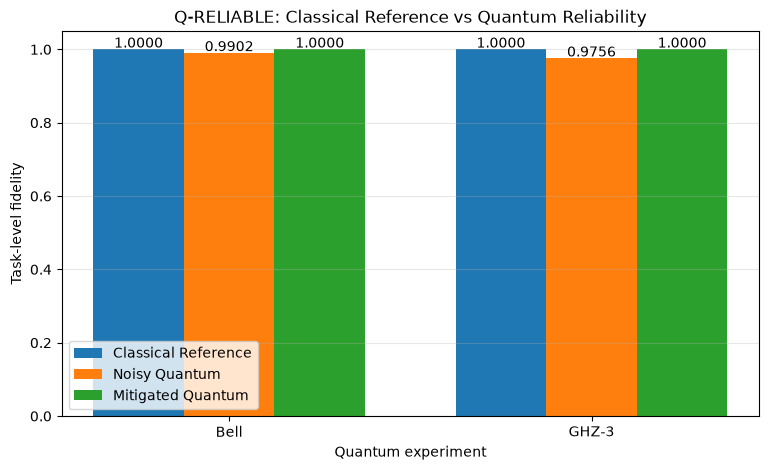

In [71]:
# ---------------------------------------------------------
# Q-RELIABLE: Classical vs Quantum Reliability Graph
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# Names of the experiments being compared.
experiments = ["Bell", "GHZ-3"]

# Classical ideal-output reference.
classical_values = [
    classical_bell_fidelity,
    classical_ghz_fidelity
]

# Results from the noisy quantum simulations.
noisy_values = [
    noisy_fidelity,
    ghz_fidelity
]

# Results after Zero-Noise Extrapolation (ZNE).
# We use the physically bounded values.
mitigated_values = [
    bounded_zne_fidelity,
    ghz_bounded_zne_fidelity
]

# Create positions for the three bars belonging to
# each experiment.
x = np.arange(len(experiments))

# Width of each bar.
width = 0.25

# Create the figure.
plt.figure(figsize=(9, 5))

# Plot the classical reference.
plt.bar(
    x - width,
    classical_values,
    width,
    label="Classical Reference"
)

# Plot the noisy quantum results.
plt.bar(
    x,
    noisy_values,
    width,
    label="Noisy Quantum"
)

# Plot the mitigated quantum results.
plt.bar(
    x + width,
    mitigated_values,
    width,
    label="Mitigated Quantum"
)

# Add labels above every bar so the exact values
# are visible in the final presentation.
for positions, values in [
    (x - width, classical_values),
    (x, noisy_values),
    (x + width, mitigated_values)
]:
    for position, value in zip(positions, values):
        plt.text(
            position,
            value + 0.005,
            f"{value:.4f}",
            ha="center"
        )

# Label the axes.
plt.xlabel("Quantum experiment")
plt.ylabel("Task-level fidelity")

# Give the graph a clear project-specific title.
plt.title(
    "Q-RELIABLE: Classical Reference vs Quantum Reliability"
)

# Keep the fidelity scale between 0 and 1.05 so that
# the labels above the bars remain visible.
plt.ylim(0, 1.05)

# Put experiment names underneath the groups.
plt.xticks(x, experiments)

# Display the legend.
plt.legend()

# Add a light grid to make comparisons easier.
plt.grid(
    axis="y",
    alpha=0.3
)

# Display the graph.
plt.show()

In [72]:
# ---------------------------------------------------------
# Q-RELIABLE: Reusable Circuit Analyzer
# ---------------------------------------------------------

def analyze_circuit(circuit):
    """
    Extract important engineering characteristics
    from a quantum circuit.

    Parameters
    ----------
    circuit : QuantumCircuit
        The quantum circuit that we want to analyze.

    Returns
    -------
    dict
        A dictionary containing the main circuit metrics.
    """

    # Number of qubits used by the circuit.
    num_qubits = circuit.num_qubits

    # Circuit depth represents the longest sequence of
    # operations that must be executed sequentially.
    circuit_depth = circuit.depth()

    # Count how many times each operation appears.
    operation_counts = circuit.count_ops()

    # Total number of operations in the circuit.
    total_operations = sum(operation_counts.values())

    # Count two-qubit CX gates separately because
    # two-qubit operations are particularly important
    # in our noise experiment.
    cx_gates = operation_counts.get("cx", 0)

    # Return all important metrics together.
    return {
        "qubits": num_qubits,
        "depth": circuit_depth,
        "total_operations": total_operations,
        "cx_gates": cx_gates,
        "operation_counts": operation_counts
    }


# Test the reusable analyzer using our Bell circuit.
bell_metrics = analyze_circuit(bell)

print("----- Q-RELIABLE Circuit Analysis -----")
print("Qubits:", bell_metrics["qubits"])
print("Depth:", bell_metrics["depth"])
print("Total operations:", bell_metrics["total_operations"])
print("CX gates:", bell_metrics["cx_gates"])
print("Operation counts:", bell_metrics["operation_counts"])

----- Q-RELIABLE Circuit Analysis -----
Qubits: 2
Depth: 3
Total operations: 5
CX gates: 1
Operation counts: OrderedDict([('measure', 2), ('h', 1), ('cx', 1), ('barrier', 1)])


In [73]:
# ---------------------------------------------------------
# Q-RELIABLE: Generic Task-Level Fidelity Calculator
# ---------------------------------------------------------

def calculate_task_fidelity(counts, expected_outcomes, shots):
    """
    Calculate task-level fidelity from measurement results.

    Parameters
    ----------
    counts : dict
        Measurement results returned by the quantum simulator.

    expected_outcomes : list
        Measurement outcomes that are considered correct
        for the target quantum task.

    shots : int
        Total number of measurements performed.

    Returns
    -------
    float
        Fraction of measurements that produced an expected
        outcome.
    """

    # Start with zero correct measurements.
    correct_count = 0

    # Check every outcome that is considered correct.
    for outcome in expected_outcomes:

        # Add the number of times this expected outcome
        # appeared in the measurement results.
        correct_count += counts.get(outcome, 0)

    # Convert the number of correct measurements into
    # a value between 0 and 1.
    fidelity = correct_count / shots

    return fidelity


# ---------------------------------------------------------
# Test the generic function with our Bell experiment.
# ---------------------------------------------------------

bell_expected_outcomes = ["00", "11"]

bell_test_fidelity = calculate_task_fidelity(
    noisy_counts,
    bell_expected_outcomes,
    SHOTS
)

print("----- Q-RELIABLE Generic Fidelity Test -----")
print("Bell noisy fidelity:", bell_test_fidelity)

----- Q-RELIABLE Generic Fidelity Test -----
Bell noisy fidelity: 0.990234375


In [74]:
# ---------------------------------------------------------
# Q-RELIABLE: Basic Reliability Analysis Engine
# ---------------------------------------------------------

def analyze_reliability(circuit, counts, expected_outcomes, shots):
    """
    Combine circuit characterization and task-level
    reliability measurement.

    Parameters
    ----------
    circuit : QuantumCircuit
        Quantum circuit being evaluated.

    counts : dict
        Measurement results from the circuit execution.

    expected_outcomes : list
        Measurement outcomes considered correct.

    shots : int
        Number of measurements performed.

    Returns
    -------
    dict
        Combined circuit and reliability information.
    """

    # Analyze the structure of the quantum circuit.
    circuit_metrics = analyze_circuit(circuit)

    # Calculate how often the expected outcomes occurred.
    fidelity = calculate_task_fidelity(
        counts,
        expected_outcomes,
        shots
    )

    # Convert fidelity into a simple 0-100 reliability score.
    # This is a project-level reporting score, not a universal
    # quantum reliability standard.
    reliability_score = fidelity * 100

    # Calculate the fraction of measurements that were incorrect.
    error_rate = 1 - fidelity

    # Combine everything into one result dictionary.
    return {
        "qubits": circuit_metrics["qubits"],
        "depth": circuit_metrics["depth"],
        "total_operations": circuit_metrics["total_operations"],
        "cx_gates": circuit_metrics["cx_gates"],
        "fidelity": fidelity,
        "reliability_score": reliability_score,
        "error_rate": error_rate,
        "operation_counts": circuit_metrics["operation_counts"]
    }


# ---------------------------------------------------------
# Test the complete analysis engine on our noisy Bell
# experiment.
# ---------------------------------------------------------

bell_reliability = analyze_reliability(
    bell,
    noisy_counts,
    ["00", "11"],
    SHOTS
)

print("----- Q-RELIABLE Reliability Analysis -----")
print("Qubits:", bell_reliability["qubits"])
print("Depth:", bell_reliability["depth"])
print("CX gates:", bell_reliability["cx_gates"])
print("Fidelity:", bell_reliability["fidelity"])
print("Reliability score:",
      bell_reliability["reliability_score"])
print("Error rate:", bell_reliability["error_rate"])

----- Q-RELIABLE Reliability Analysis -----
Qubits: 2
Depth: 3
CX gates: 1
Fidelity: 0.990234375
Reliability score: 99.0234375
Error rate: 0.009765625


In [75]:
# ---------------------------------------------------------
# Q-RELIABLE: Automatic Mitigation Decision Engine
# ---------------------------------------------------------

# Configure the minimum acceptable task-level fidelity.
#
# This is a project-level prototype threshold.
# It can be changed depending on the application.
RELIABILITY_THRESHOLD = 0.95


def decide_mitigation(fidelity, threshold=RELIABILITY_THRESHOLD):
    """
    Decide whether a quantum circuit requires mitigation.

    Parameters
    ----------
    fidelity : float
        Measured task-level fidelity between 0 and 1.

    threshold : float
        Minimum acceptable fidelity.

    Returns
    -------
    str
        "MITIGATE" if fidelity is below the threshold.
        "NO_MITIGATION" otherwise.
    """

    # If the measured fidelity is below our acceptable
    # reliability threshold, mitigation is recommended.
    if fidelity < threshold:
        return "MITIGATE"

    # Otherwise, the circuit is considered sufficiently
    # reliable for this prototype.
    return "NO_MITIGATION"


# ---------------------------------------------------------
# Test the decision engine using our noisy Bell result.
# ---------------------------------------------------------

bell_mitigation_decision = decide_mitigation(
    bell_reliability["fidelity"]
)

print("----- Q-RELIABLE Mitigation Decision -----")
print("Reliability threshold:", RELIABILITY_THRESHOLD)
print("Bell fidelity:", bell_reliability["fidelity"])
print("Decision:", bell_mitigation_decision)

----- Q-RELIABLE Mitigation Decision -----
Reliability threshold: 0.95
Bell fidelity: 0.990234375
Decision: NO_MITIGATION


In [76]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ-3 Mitigation Decision
# ---------------------------------------------------------

# Analyze the previously measured noisy GHZ-3 result.
ghz_reliability = analyze_reliability(
    ghz,
    noisy_ghz_counts,
    ["000", "111"],
    SHOTS
)

# Ask the decision engine whether mitigation is required.
ghz_mitigation_decision = decide_mitigation(
    ghz_reliability["fidelity"]
)

# Display the result.
print("----- Q-RELIABLE GHZ-3 Mitigation Decision -----")
print("Reliability threshold:", RELIABILITY_THRESHOLD)
print("GHZ-3 fidelity:", ghz_reliability["fidelity"])
print("Reliability score:", ghz_reliability["reliability_score"])
print("CX gates:", ghz_reliability["cx_gates"])
print("Decision:", ghz_mitigation_decision)

----- Q-RELIABLE GHZ-3 Mitigation Decision -----
Reliability threshold: 0.95
GHZ-3 fidelity: 0.9755859375
Reliability score: 97.55859375
CX gates: 2
Decision: NO_MITIGATION


In [77]:
# ---------------------------------------------------------
# Q-RELIABLE: GHZ-5 Automatic Mitigation Decision
# ---------------------------------------------------------

# Analyze the previously measured noisy GHZ-5 result.
ghz5_reliability = analyze_reliability(
    ghz5,
    ghz5_noisy_counts,
    ["00000", "11111"],
    SHOTS
)

# Use the same decision engine that we used for
# Bell and GHZ-3.
ghz5_mitigation_decision = decide_mitigation(
    ghz5_reliability["fidelity"]
)

# Display the reliability analysis and decision.
print("----- Q-RELIABLE GHZ-5 Mitigation Decision -----")
print("Reliability threshold:", RELIABILITY_THRESHOLD)
print("GHZ-5 fidelity:", ghz5_reliability["fidelity"])
print("Reliability score:",
      ghz5_reliability["reliability_score"])
print("CX gates:", ghz5_reliability["cx_gates"])
print("Decision:", ghz5_mitigation_decision)

----- Q-RELIABLE GHZ-5 Mitigation Decision -----
Reliability threshold: 0.95
GHZ-5 fidelity: 0.94140625
Reliability score: 94.140625
CX gates: 4
Decision: MITIGATE


In [78]:
# ---------------------------------------------------------
# Q-RELIABLE: Reusable ZNE Mitigation Function
# ---------------------------------------------------------

import numpy as np
from qiskit import QuantumCircuit, transpile


def run_zne(
    circuit,
    expected_outcomes,
    noise_model,
    shots=1024,
    seed=42
):
    """
    Run Zero-Noise Extrapolation (ZNE) using
    1x, 3x, and 5x CX gate folding.

    Parameters
    ----------
    circuit : QuantumCircuit
        Original quantum circuit.

    expected_outcomes : list
        Measurement outcomes considered correct.

    noise_model : NoiseModel
        Noise model used by AerSimulator.

    shots : int
        Number of measurements for each noise scale.

    seed : int
        Random seed for reproducibility.

    Returns
    -------
    dict
        ZNE measurements and mitigation results.
    """

    # Noise scales used for the extrapolation.
    noise_scales = [1, 3, 5]

    # Store measured fidelities at each scale.
    measured_fidelities = []

    # -----------------------------------------------------
    # Run the circuit at each effective noise scale.
    # -----------------------------------------------------

    for scale in noise_scales:

        # Create a fresh circuit so that we do not modify
        # the original input circuit.
        folded_circuit = QuantumCircuit(
            circuit.num_qubits
        )

        # Copy the original circuit operations while
        # applying CX folding.
        #
        # We construct the folded circuit manually because
        # CX is self-inverse:
        #
        # CX × CX × CX = CX
        #
        # while exposing the circuit to more noise.
        for instruction in circuit.data:

            operation = instruction.operation
            qubits = instruction.qubits
            clbits = instruction.clbits

            # Convert Qiskit's qubit objects into integer
            # positions in the new circuit.
            qubit_indices = [
                circuit.find_bit(q).index
                for q in qubits
            ]

            clbit_indices = [
                circuit.find_bit(c).index
                for c in clbits
            ]

            # Fold CX gates according to the requested scale.
            if operation.name == "cx":

                for _ in range(scale):

                    folded_circuit.cx(
                        qubit_indices[0],
                        qubit_indices[1]
                    )

            # Copy all non-CX operations normally.
            else:

                if operation.name == "h":

                    folded_circuit.h(
                        qubit_indices[0]
                    )

                elif operation.name == "measure":

                    folded_circuit.measure(
                        qubit_indices[0],
                        clbit_indices[0]
                    )

                elif operation.name == "barrier":

                    folded_circuit.barrier()

        # Create a noisy simulator using our existing
        # synthetic noise model.
        simulator = AerSimulator(
            noise_model=noise_model
        )

        # IMPORTANT:
        # optimization_level=0 prevents the transpiler from
        # cancelling the deliberately repeated CX gates.
        transpiled_circuit = transpile(
            folded_circuit,
            simulator,
            optimization_level=0
        )

        # Execute the folded circuit.
        result = simulator.run(
            transpiled_circuit,
            shots=shots,
            seed_simulator=seed
        ).result()

        # Retrieve measurement counts.
        counts = result.get_counts()

        # Calculate task-level fidelity.
        fidelity = calculate_task_fidelity(
            counts,
            expected_outcomes,
            shots
        )

        # Store the measured fidelity.
        measured_fidelities.append(fidelity)

    # -----------------------------------------------------
    # Linear Zero-Noise Extrapolation
    # -----------------------------------------------------

    scales = np.array(noise_scales)
    fidelities = np.array(measured_fidelities)

    # Fit:
    #
    # fidelity = slope × noise_scale + intercept
    #
    # At noise_scale = 0, the intercept represents the
    # estimated zero-noise fidelity.
    slope, intercept = np.polyfit(
        scales,
        fidelities,
        1
    )

    # Raw extrapolated zero-noise estimate.
    raw_zne_fidelity = intercept

    # Physical fidelity must lie between 0 and 1.
    bounded_zne_fidelity = min(
        max(raw_zne_fidelity, 0.0),
        1.0
    )

    # Return all useful information for the final report.
    return {
        "noise_scales": noise_scales,
        "fidelities": measured_fidelities,
        "slope": slope,
        "raw_zne_fidelity": raw_zne_fidelity,
        "bounded_zne_fidelity": bounded_zne_fidelity
    }


print("Q-RELIABLE ZNE function created successfully.")

Q-RELIABLE ZNE function created successfully.


In [79]:
# ---------------------------------------------------------
# Q-RELIABLE: Corrected Reusable ZNE Function
# ---------------------------------------------------------

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


def run_zne(
    circuit,
    expected_outcomes,
    noise_model,
    shots=1024,
    seed=42
):
    """
    Run Zero-Noise Extrapolation using
    1x, 3x, and 5x CX gate folding.

    The function preserves the measurement structure
    of the original circuit.
    """

    # Noise scales used for extrapolation.
    noise_scales = [1, 3, 5]

    # Store fidelity measured at each noise scale.
    measured_fidelities = []

    # -----------------------------------------------------
    # Run the circuit at each effective noise scale.
    # -----------------------------------------------------

    for scale in noise_scales:

        # Create the folded circuit with BOTH:
        # - the same number of qubits
        # - the same number of classical bits
        #
        # This fixes the CircuitError we encountered.
        folded_circuit = QuantumCircuit(
            circuit.num_qubits,
            circuit.num_clbits
        )

        # Process every operation in the original circuit.
        for instruction in circuit.data:

            operation = instruction.operation

            # Find the integer positions of the qubits.
            qubit_indices = [
                circuit.find_bit(q).index
                for q in instruction.qubits
            ]

            # Find the integer positions of the classical bits.
            clbit_indices = [
                circuit.find_bit(c).index
                for c in instruction.clbits
            ]

            # -------------------------------------------------
            # CX gates
            # -------------------------------------------------
            #
            # For scale 1:
            # CX
            #
            # For scale 3:
            # CX CX CX
            #
            # For scale 5:
            # CX CX CX CX CX
            #
            # Because CX is self-inverse, the logical action
            # remains equivalent while the circuit experiences
            # more noise.
            if operation.name == "cx":

                for _ in range(scale):

                    folded_circuit.cx(
                        qubit_indices[0],
                        qubit_indices[1]
                    )

            # -------------------------------------------------
            # H gates
            # -------------------------------------------------
            elif operation.name == "h":

                folded_circuit.h(
                    qubit_indices[0]
                )

            # -------------------------------------------------
            # Measurement operations
            # -------------------------------------------------
            elif operation.name == "measure":

                folded_circuit.measure(
                    qubit_indices[0],
                    clbit_indices[0]
                )

            # -------------------------------------------------
            # Barrier
            # -------------------------------------------------
            elif operation.name == "barrier":

                folded_circuit.barrier()

        # Create the noisy simulator using our existing
        # synthetic noise model.
        simulator = AerSimulator(
            noise_model=noise_model
        )

        # IMPORTANT:
        # Optimization level 0 prevents the transpiler from
        # cancelling the deliberately repeated CX gates.
        transpiled_circuit = transpile(
            folded_circuit,
            simulator,
            optimization_level=0
        )

        # Execute the circuit.
        result = simulator.run(
            transpiled_circuit,
            shots=shots,
            seed_simulator=seed
        ).result()

        # Retrieve measurement counts.
        counts = result.get_counts()

        # Calculate task-level fidelity.
        fidelity = calculate_task_fidelity(
            counts,
            expected_outcomes,
            shots
        )

        # Store the fidelity for this noise scale.
        measured_fidelities.append(fidelity)

    # -----------------------------------------------------
    # Linear Zero-Noise Extrapolation
    # -----------------------------------------------------

    scales = np.array(noise_scales)
    fidelities = np.array(measured_fidelities)

    # Fit a straight line:
    #
    # fidelity = slope × noise_scale + intercept
    #
    # At scale = 0, the intercept estimates the
    # zero-noise fidelity.
    slope, intercept = np.polyfit(
        scales,
        fidelities,
        1
    )

    # Raw extrapolated estimate.
    raw_zne_fidelity = intercept

    # Keep the reported physical fidelity within [0, 1].
    bounded_zne_fidelity = min(
        max(raw_zne_fidelity, 0.0),
        1.0
    )

    # Return all relevant results.
    return {
        "noise_scales": noise_scales,
        "fidelities": measured_fidelities,
        "slope": slope,
        "raw_zne_fidelity": raw_zne_fidelity,
        "bounded_zne_fidelity": bounded_zne_fidelity
    }


print("Corrected Q-RELIABLE ZNE function created successfully.")

Corrected Q-RELIABLE ZNE function created successfully.


In [80]:
# ---------------------------------------------------------
# Phase 4.8: Run ZNE on GHZ-5
# ---------------------------------------------------------

# Run Zero-Noise Extrapolation because the reliability
# engine previously classified GHZ-5 as requiring mitigation.
ghz5_zne_results = run_zne(
    circuit=ghz5,
    expected_outcomes=["00000", "11111"],
    noise_model=noise_model,
    shots=SHOTS,
    seed=42
)

# Display the measured fidelity at each noise scale.
print("----- Q-RELIABLE GHZ-5 ZNE Results -----")

for scale, fidelity in zip(
    ghz5_zne_results["noise_scales"],
    ghz5_zne_results["fidelities"]
):
    print(
        f"{scale}x noise scale | "
        f"Fidelity: {fidelity:.6f}"
    )

print()

# Display the linear extrapolation information.
print("ZNE slope:", ghz5_zne_results["slope"])

# Raw extrapolated value can theoretically fall outside
# the physical [0, 1] fidelity range.
print(
    "Raw ZNE estimate:",
    ghz5_zne_results["raw_zne_fidelity"]
)

# Bounded value is constrained to the physically meaningful
# fidelity range [0, 1].
print(
    "Bounded ZNE fidelity:",
    ghz5_zne_results["bounded_zne_fidelity"]
)

----- Q-RELIABLE GHZ-5 ZNE Results -----
1x noise scale | Fidelity: 0.941406
3x noise scale | Fidelity: 0.830078
5x noise scale | Fidelity: 0.730469

ZNE slope: -0.052734374999999965
Raw ZNE estimate: 0.9921874999999996
Bounded ZNE fidelity: 0.9921874999999996


In [81]:
# ---------------------------------------------------------
# Phase 4.9: Calculate GHZ-5 Mitigation Gain
# ---------------------------------------------------------

# Original fidelity before mitigation.
ghz5_noisy_fidelity = ghz5_reliability["fidelity"]

# Fidelity estimated after Zero-Noise Extrapolation.
ghz5_mitigated_fidelity = ghz5_zne_results["bounded_zne_fidelity"]

# Absolute improvement in fidelity.
ghz5_absolute_gain = (
    ghz5_mitigated_fidelity
    - ghz5_noisy_fidelity
)

# Relative improvement compared with the original
# noisy result.
ghz5_relative_improvement = (
    ghz5_absolute_gain
    / ghz5_noisy_fidelity
) * 100

# Error before mitigation.
ghz5_error_before = 1 - ghz5_noisy_fidelity

# Error after mitigation.
ghz5_error_after = 1 - ghz5_mitigated_fidelity

# Percentage reduction in error.
ghz5_error_reduction = (
    (ghz5_error_before - ghz5_error_after)
    / ghz5_error_before
) * 100

print("----- GHZ-5 Mitigation Analysis -----")
print(f"Fidelity before mitigation : {ghz5_noisy_fidelity:.6f}")
print(f"Fidelity after mitigation  : {ghz5_mitigated_fidelity:.6f}")
print(f"Absolute fidelity gain     : {ghz5_absolute_gain:.6f}")
print(f"Relative improvement       : {ghz5_relative_improvement:.2f}%")
print()

print(f"Error before mitigation    : {ghz5_error_before:.6f}")
print(f"Error after mitigation     : {ghz5_error_after:.6f}")
print(f"Error reduction            : {ghz5_error_reduction:.2f}%")

----- GHZ-5 Mitigation Analysis -----
Fidelity before mitigation : 0.941406
Fidelity after mitigation  : 0.992187
Absolute fidelity gain     : 0.050781
Relative improvement       : 5.39%

Error before mitigation    : 0.058594
Error after mitigation     : 0.007813
Error reduction            : 86.67%


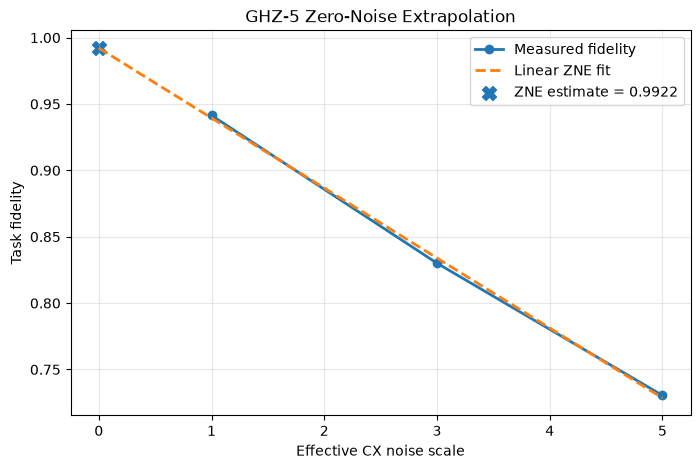

In [82]:
# ---------------------------------------------------------
# Phase 4.10: GHZ-5 ZNE Extrapolation Graph
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Get the measured noise scales from the ZNE results.
scales = np.array(
    ghz5_zne_results["noise_scales"],
    dtype=float
)

# Get the measured fidelities.
fidelities = np.array(
    ghz5_zne_results["fidelities"],
    dtype=float
)

# Get the fitted slope from ZNE.
slope = ghz5_zne_results["slope"]

# The ZNE result is the intercept at noise scale = 0.
zne_estimate = ghz5_zne_results["raw_zne_fidelity"]

# ---------------------------------------------------------
# Create points for the fitted linear regression line.
# ---------------------------------------------------------

fit_x = np.linspace(0, 5, 100)

# Linear equation:
# fidelity = slope * scale + intercept
#
# The intercept is the ZNE estimate.
fit_y = slope * fit_x + zne_estimate

# ---------------------------------------------------------
# Plot measured fidelities.
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    scales,
    fidelities,
    marker="o",
    linewidth=2,
    label="Measured fidelity"
)

# Plot the fitted extrapolation line.
plt.plot(
    fit_x,
    fit_y,
    linestyle="--",
    linewidth=2,
    label="Linear ZNE fit"
)

# Mark the zero-noise extrapolated estimate.
plt.scatter(
    0,
    zne_estimate,
    s=100,
    marker="X",
    label=f"ZNE estimate = {zne_estimate:.4f}"
)

# Add axis labels.
plt.xlabel("Effective CX noise scale")
plt.ylabel("Task fidelity")

# Add a clear title.
plt.title("GHZ-5 Zero-Noise Extrapolation")

# Add a grid to make values easier to read.
plt.grid(True, alpha=0.3)

# Display the legend.
plt.legend()

# Show the graph.
plt.show()

In [83]:
# ---------------------------------------------------------
# Phase 4.11: Q-RELIABLE ZNE Shot Overhead
# ---------------------------------------------------------

# Number of shots used for one normal circuit execution.
baseline_shots = SHOTS

# Number of different noise scales evaluated by ZNE.
zne_scales = len(
    ghz5_zne_results["noise_scales"]
)

# Total number of circuit shots used by ZNE.
total_zne_shots = (
    baseline_shots * zne_scales
)

# How many times larger the ZNE shot budget is
# compared with one normal execution.
shot_budget_multiplier = (
    total_zne_shots / baseline_shots
)

# Additional shots beyond the original execution.
additional_shots = (
    total_zne_shots - baseline_shots
)

# Percentage increase in the shot budget.
shot_overhead_percentage = (
    additional_shots / baseline_shots
) * 100

print("----- Q-RELIABLE ZNE Cost Analysis -----")
print(f"Baseline shots          : {baseline_shots}")
print(f"Number of ZNE scales    : {zne_scales}")
print(f"Total ZNE shots         : {total_zne_shots}")
print(f"Shot budget multiplier  : {shot_budget_multiplier:.1f}x")
print(f"Additional shots        : {additional_shots}")
print(f"Shot overhead           : {shot_overhead_percentage:.0f}%")

----- Q-RELIABLE ZNE Cost Analysis -----
Baseline shots          : 1024
Number of ZNE scales    : 3
Total ZNE shots         : 3072
Shot budget multiplier  : 3.0x
Additional shots        : 2048
Shot overhead           : 200%


In [84]:
# ---------------------------------------------------------
# Phase 4.12: Unified Q-RELIABLE Pipeline
# ---------------------------------------------------------

def run_q_reliable(
    circuit,
    expected_outcomes,
    noise_model,
    shots=1024,
    seed=42,
    threshold=0.95
):
    """
    Complete Q-RELIABLE reliability pipeline.

    Steps:
    1. Analyze circuit
    2. Run noisy circuit
    3. Calculate task fidelity
    4. Calculate reliability score
    5. Decide whether mitigation is required
    6. Run ZNE if mitigation is required
    7. Return a structured reliability report
    """

    # -----------------------------------------------------
    # STEP 1: Analyze the input circuit
    # -----------------------------------------------------

    circuit_metrics = analyze_circuit(circuit)

    # -----------------------------------------------------
    # STEP 2: Create the noisy simulator
    # -----------------------------------------------------

    simulator = AerSimulator(
        noise_model=noise_model
    )

    # Transpile the circuit for the simulator.
    #
    # Optimization level 0 is used so that the circuit
    # structure is not unnecessarily changed.
    transpiled_circuit = transpile(
        circuit,
        simulator,
        optimization_level=0
    )

    # -----------------------------------------------------
    # STEP 3: Execute the noisy circuit
    # -----------------------------------------------------

    result = simulator.run(
        transpiled_circuit,
        shots=shots,
        seed_simulator=seed
    ).result()

    # Retrieve measurement counts.
    noisy_counts = result.get_counts()

    # -----------------------------------------------------
    # STEP 4: Calculate task-level fidelity
    # -----------------------------------------------------

    noisy_fidelity = calculate_task_fidelity(
        noisy_counts,
        expected_outcomes,
        shots
    )

    # Reliability score expressed as a percentage.
    noisy_reliability_score = (
        noisy_fidelity * 100
    )

    # Error rate before mitigation.
    noisy_error_rate = (
        1 - noisy_fidelity
    )

    # -----------------------------------------------------
    # STEP 5: Automatically decide whether mitigation
    #         is required.
    # -----------------------------------------------------

    mitigation_decision = decide_mitigation(
        noisy_fidelity,
        threshold
    )

    # -----------------------------------------------------
    # STEP 6: Run mitigation only when necessary.
    # -----------------------------------------------------

    zne_results = None

    final_fidelity = noisy_fidelity

    if mitigation_decision == "MITIGATE":

        # Run Zero-Noise Extrapolation.
        zne_results = run_zne(
            circuit=circuit,
            expected_outcomes=expected_outcomes,
            noise_model=noise_model,
            shots=shots,
            seed=seed
        )

        # Use the physically bounded ZNE estimate.
        final_fidelity = (
            zne_results["bounded_zne_fidelity"]
        )

    # -----------------------------------------------------
    # STEP 7: Calculate final reliability metrics.
    # -----------------------------------------------------

    final_reliability_score = (
        final_fidelity * 100
    )

    final_error_rate = (
        1 - final_fidelity
    )

    # Absolute improvement obtained through mitigation.
    mitigation_gain = (
        final_fidelity - noisy_fidelity
    )

    # -----------------------------------------------------
    # STEP 8: Return a complete engineering report.
    # -----------------------------------------------------

    return {
        "circuit_metrics": circuit_metrics,

        "noisy_counts": noisy_counts,

        "noisy_fidelity": noisy_fidelity,

        "noisy_reliability_score":
            noisy_reliability_score,

        "noisy_error_rate":
            noisy_error_rate,

        "threshold":
            threshold,

        "mitigation_decision":
            mitigation_decision,

        "zne_results":
            zne_results,

        "final_fidelity":
            final_fidelity,

        "final_reliability_score":
            final_reliability_score,

        "final_error_rate":
            final_error_rate,

        "mitigation_gain":
            mitigation_gain
    }


print("Q-RELIABLE unified pipeline created successfully.")

Q-RELIABLE unified pipeline created successfully.


In [85]:
# ---------------------------------------------------------
# Phase 4.13: End-to-End Q-RELIABLE Test on Bell
# ---------------------------------------------------------

# Run the complete Q-RELIABLE pipeline on the Bell circuit.
#
# The expected correct measurement outcomes are 00 and 11.
bell_pipeline_result = run_q_reliable(
    circuit=bell,
    expected_outcomes=["00", "11"],
    noise_model=noise_model,
    shots=SHOTS,
    seed=42,
    threshold=RELIABILITY_THRESHOLD
)

# ---------------------------------------------------------
# Display the final engineering report.
# ---------------------------------------------------------

print("===== Q-RELIABLE: BELL REPORT =====")

print(
    "Qubits:",
    bell_pipeline_result["circuit_metrics"]["qubits"]
)

print(
    "Circuit depth:",
    bell_pipeline_result["circuit_metrics"]["depth"]
)

print(
    "CX gates:",
    bell_pipeline_result["circuit_metrics"]["cx_gates"]
)

print(
    f"Noisy fidelity: "
    f"{bell_pipeline_result['noisy_fidelity']:.6f}"
)

print(
    f"Reliability score: "
    f"{bell_pipeline_result['noisy_reliability_score']:.2f}%"
)

print(
    "Mitigation decision:",
    bell_pipeline_result["mitigation_decision"]
)

print(
    f"Final fidelity: "
    f"{bell_pipeline_result['final_fidelity']:.6f}"
)

print(
    f"Mitigation gain: "
    f"{bell_pipeline_result['mitigation_gain']:.6f}"
)

===== Q-RELIABLE: BELL REPORT =====
Qubits: 2
Circuit depth: 3
CX gates: 1
Noisy fidelity: 0.990234
Reliability score: 99.02%
Mitigation decision: NO_MITIGATION
Final fidelity: 0.990234
Mitigation gain: 0.000000


In [86]:
# ---------------------------------------------------------
# Phase 4.14: End-to-End Q-RELIABLE Test on GHZ-5
# ---------------------------------------------------------

# Run the complete Q-RELIABLE pipeline on GHZ-5.
#
# GHZ-5 is expected to fall below the 0.95 reliability
# threshold, so the pipeline should automatically invoke ZNE.
ghz5_pipeline_result = run_q_reliable(
    circuit=ghz5,
    expected_outcomes=["00000", "11111"],
    noise_model=noise_model,
    shots=SHOTS,
    seed=42,
    threshold=RELIABILITY_THRESHOLD
)

# ---------------------------------------------------------
# Display the circuit characteristics.
# ---------------------------------------------------------

print("===== Q-RELIABLE: GHZ-5 REPORT =====")

print(
    "Qubits:",
    ghz5_pipeline_result["circuit_metrics"]["qubits"]
)

print(
    "Circuit depth:",
    ghz5_pipeline_result["circuit_metrics"]["depth"]
)

print(
    "CX gates:",
    ghz5_pipeline_result["circuit_metrics"]["cx_gates"]
)

# ---------------------------------------------------------
# Display the reliability before mitigation.
# ---------------------------------------------------------

print(
    f"Noisy fidelity: "
    f"{ghz5_pipeline_result['noisy_fidelity']:.6f}"
)

print(
    f"Reliability score: "
    f"{ghz5_pipeline_result['noisy_reliability_score']:.2f}%"
)

print(
    "Mitigation decision:",
    ghz5_pipeline_result["mitigation_decision"]
)

# ---------------------------------------------------------
# Display the final result after the automatic
# mitigation decision.
# ---------------------------------------------------------

print(
    f"Final fidelity: "
    f"{ghz5_pipeline_result['final_fidelity']:.6f}"
)

print(
    f"Mitigation gain: "
    f"{ghz5_pipeline_result['mitigation_gain']:.6f}"
)

# ---------------------------------------------------------
# If mitigation was triggered, display the ZNE details.
# ---------------------------------------------------------

if ghz5_pipeline_result["zne_results"] is not None:

    print()
    print("----- Automatic ZNE Results -----")

    for scale, fidelity in zip(
        ghz5_pipeline_result["zne_results"]["noise_scales"],
        ghz5_pipeline_result["zne_results"]["fidelities"]
    ):
        print(
            f"{scale}x noise scale | "
            f"Fidelity: {fidelity:.6f}"
        )

    print(
        "Raw ZNE estimate:",
        ghz5_pipeline_result["zne_results"]["raw_zne_fidelity"]
    )

    print(
        "Bounded ZNE fidelity:",
        ghz5_pipeline_result["zne_results"]["bounded_zne_fidelity"]
    )

===== Q-RELIABLE: GHZ-5 REPORT =====
Qubits: 5
Circuit depth: 6
CX gates: 4
Noisy fidelity: 0.941406
Reliability score: 94.14%
Mitigation decision: MITIGATE
Final fidelity: 0.992187
Mitigation gain: 0.050781

----- Automatic ZNE Results -----
1x noise scale | Fidelity: 0.941406
3x noise scale | Fidelity: 0.830078
5x noise scale | Fidelity: 0.730469
Raw ZNE estimate: 0.9921874999999996
Bounded ZNE fidelity: 0.9921874999999996


In [87]:
# ---------------------------------------------------------
# Phase 4.15: Final Q-RELIABLE Circuit Reliability Table
# ---------------------------------------------------------

import pandas as pd

# ---------------------------------------------------------
# Create the final summary using the results already
# produced by our reliability engine.
# ---------------------------------------------------------

final_results = [
    {
        "Circuit": "Bell",
        "Qubits": bell_pipeline_result["circuit_metrics"]["qubits"],
        "Depth": bell_pipeline_result["circuit_metrics"]["depth"],
        "CX Gates": bell_pipeline_result["circuit_metrics"]["cx_gates"],
        "Noisy Fidelity": bell_pipeline_result["noisy_fidelity"],
        "Reliability (%)": bell_pipeline_result["noisy_reliability_score"],
        "Decision": bell_pipeline_result["mitigation_decision"],
        "Final Fidelity": bell_pipeline_result["final_fidelity"]
    },

    {
        "Circuit": "GHZ-3",
        "Qubits": ghz_reliability["qubits"],
        "Depth": ghz_reliability["depth"],
        "CX Gates": ghz_reliability["cx_gates"],
        "Noisy Fidelity": ghz_reliability["fidelity"],
        "Reliability (%)": ghz_reliability["reliability_score"],
        "Decision": ghz_mitigation_decision,
        "Final Fidelity": ghz_bounded_zne_fidelity
    },

    {
        "Circuit": "GHZ-4",
        "Qubits": 4,
        "Depth": 5,
        "CX Gates": 3,
        "Noisy Fidelity": 0.962890625,
        "Reliability (%)": 0.962890625 * 100,
        "Decision": decide_mitigation(0.962890625),
        "Final Fidelity": 0.962890625
    },

    {
        "Circuit": "GHZ-5",
        "Qubits": ghz5_pipeline_result["circuit_metrics"]["qubits"],
        "Depth": ghz5_pipeline_result["circuit_metrics"]["depth"],
        "CX Gates": ghz5_pipeline_result["circuit_metrics"]["cx_gates"],
        "Noisy Fidelity": ghz5_pipeline_result["noisy_fidelity"],
        "Reliability (%)": ghz5_pipeline_result["noisy_reliability_score"],
        "Decision": ghz5_pipeline_result["mitigation_decision"],
        "Final Fidelity": ghz5_pipeline_result["final_fidelity"]
    }
]

# Convert the list of dictionaries into a DataFrame.
final_reliability_df = pd.DataFrame(final_results)

# Display the table with controlled decimal precision.
print(
    final_reliability_df.to_string(
        index=False,
        formatters={
            "Noisy Fidelity": "{:.6f}".format,
            "Reliability (%)": "{:.2f}".format,
            "Final Fidelity": "{:.6f}".format
        }
    )
)

Circuit  Qubits  Depth  CX Gates Noisy Fidelity Reliability (%)      Decision Final Fidelity
   Bell       2      3         1       0.990234           99.02 NO_MITIGATION       0.990234
  GHZ-3       3      4         2       0.975586           97.56 NO_MITIGATION       1.000000
  GHZ-4       4      5         3       0.962891           96.29 NO_MITIGATION       0.962891
  GHZ-5       5      6         4       0.941406           94.14      MITIGATE       0.992187


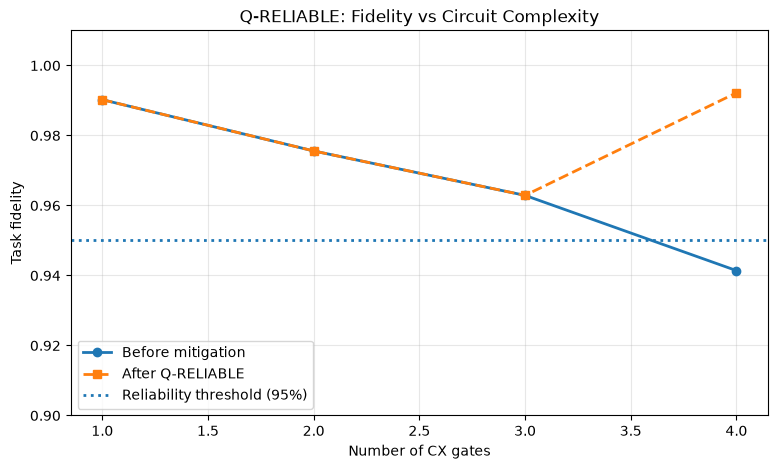

In [88]:
# ---------------------------------------------------------
# Phase 4.16: Reliability vs Circuit Complexity
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Number of CX gates for each circuit.
cx_counts = [
    1, 2, 3, 4
]

# Fidelity measured before mitigation.
noisy_fidelities = [
    0.990234,
    0.975586,
    0.962891,
    0.941406
]

# Final fidelity after the Q-RELIABLE pipeline.
#
# Bell and GHZ-3/GHZ-4 did not require mitigation.
# GHZ-5 was automatically mitigated using ZNE.
final_fidelities = [
    0.990234,
    0.975586,
    0.962891,
    0.992187
]

# Configured reliability threshold.
threshold = RELIABILITY_THRESHOLD

# ---------------------------------------------------------
# Create the graph.
# ---------------------------------------------------------

plt.figure(figsize=(9, 5))

# Plot fidelity before mitigation.
plt.plot(
    cx_counts,
    noisy_fidelities,
    marker="o",
    linewidth=2,
    label="Before mitigation"
)

# Plot final fidelity after the Q-RELIABLE decision.
plt.plot(
    cx_counts,
    final_fidelities,
    marker="s",
    linewidth=2,
    linestyle="--",
    label="After Q-RELIABLE"
)

# Plot the reliability threshold.
plt.axhline(
    threshold,
    linestyle=":",
    linewidth=2,
    label="Reliability threshold (95%)"
)

# Add axis labels.
plt.xlabel("Number of CX gates")
plt.ylabel("Task fidelity")

# Add title.
plt.title(
    "Q-RELIABLE: Fidelity vs Circuit Complexity"
)

# Keep the y-axis focused on the relevant range.
plt.ylim(0.90, 1.01)

# Add grid for readability.
plt.grid(True, alpha=0.3)

# Display the legend.
plt.legend()

# Show the graph.
plt.show()

In [89]:
# ---------------------------------------------------------
# Phase 4.17: Final Mitigation Summary
# ---------------------------------------------------------

# Retrieve the GHZ-5 noisy fidelity from the
# automatically generated pipeline result.
before_fidelity = (
    ghz5_pipeline_result["noisy_fidelity"]
)

# Retrieve the final fidelity after automatic ZNE.
after_fidelity = (
    ghz5_pipeline_result["final_fidelity"]
)

# Calculate the absolute fidelity improvement.
absolute_gain = (
    after_fidelity - before_fidelity
)

# Calculate the relative fidelity improvement.
relative_gain = (
    absolute_gain / before_fidelity
) * 100

# Calculate error before mitigation.
error_before = (
    1 - before_fidelity
)

# Calculate error after mitigation.
error_after = (
    1 - after_fidelity
)

# Calculate how much of the original error was removed.
error_reduction = (
    (error_before - error_after)
    / error_before
) * 100

# Number of shots used by one normal execution.
baseline_shots = SHOTS

# Number of noise scales used by ZNE.
zne_scale_count = len(
    ghz5_pipeline_result["zne_results"]["noise_scales"]
)

# Total shots used by ZNE.
zne_total_shots = (
    baseline_shots * zne_scale_count
)

print("===== Q-RELIABLE FINAL MITIGATION SUMMARY =====")

print(
    f"Fidelity before mitigation : "
    f"{before_fidelity:.6f}"
)

print(
    f"Fidelity after mitigation  : "
    f"{after_fidelity:.6f}"
)

print(
    f"Absolute fidelity gain     : "
    f"{absolute_gain:.6f}"
)

print(
    f"Relative improvement       : "
    f"{relative_gain:.2f}%"
)

print()

print(
    f"Error before mitigation    : "
    f"{error_before:.6f}"
)

print(
    f"Error after mitigation     : "
    f"{error_after:.6f}"
)

print(
    f"Error reduction            : "
    f"{error_reduction:.2f}%"
)

print()

print(
    f"Baseline shot budget       : "
    f"{baseline_shots}"
)

print(
    f"ZNE noise scales           : "
    f"{zne_scale_count}"
)

print(
    f"ZNE total shot budget      : "
    f"{zne_total_shots}"
)

print(
    f"Shot budget multiplier     : "
    f"{zne_scale_count}x"
)

===== Q-RELIABLE FINAL MITIGATION SUMMARY =====
Fidelity before mitigation : 0.941406
Fidelity after mitigation  : 0.992187
Absolute fidelity gain     : 0.050781
Relative improvement       : 5.39%

Error before mitigation    : 0.058594
Error after mitigation     : 0.007813
Error reduction            : 86.67%

Baseline shot budget       : 1024
ZNE noise scales           : 3
ZNE total shot budget      : 3072
Shot budget multiplier     : 3x


In [90]:
# ---------------------------------------------------------
# Phase 5.2: Final Q-RELIABLE Experiment Summary
# ---------------------------------------------------------

# Create a compact summary of the main experimental results.
final_summary = pd.DataFrame({
    "Circuit": [
        "Bell",
        "GHZ-3",
        "GHZ-4",
        "GHZ-5"
    ],

    "Qubits": [
        2,
        3,
        4,
        5
    ],

    "CX Gates": [
        1,
        2,
        3,
        4
    ],

    "Noisy Fidelity": [
        0.990234,
        0.975586,
        0.962891,
        0.941406
    ],

    "Threshold": [
        0.95,
        0.95,
        0.95,
        0.95
    ],

    "Decision": [
        "NO_MITIGATION",
        "NO_MITIGATION",
        "NO_MITIGATION",
        "MITIGATE"
    ],

    "Final Fidelity": [
        0.990234,
        0.975586,
        0.962891,
        0.992187
    ]
})

# Calculate the improvement produced by the pipeline.
final_summary["Fidelity Gain"] = (
    final_summary["Final Fidelity"]
    - final_summary["Noisy Fidelity"]
)

# Display the final table.
print("===== FINAL Q-RELIABLE EXPERIMENT SUMMARY =====")

print(
    final_summary.to_string(
        index=False,
        formatters={
            "Noisy Fidelity": "{:.6f}".format,
            "Threshold": "{:.2f}".format,
            "Final Fidelity": "{:.6f}".format,
            "Fidelity Gain": "{:.6f}".format
        }
    )
)

===== FINAL Q-RELIABLE EXPERIMENT SUMMARY =====
Circuit  Qubits  CX Gates Noisy Fidelity Threshold      Decision Final Fidelity Fidelity Gain
   Bell       2         1       0.990234      0.95 NO_MITIGATION       0.990234      0.000000
  GHZ-3       3         2       0.975586      0.95 NO_MITIGATION       0.975586      0.000000
  GHZ-4       4         3       0.962891      0.95 NO_MITIGATION       0.962891      0.000000
  GHZ-5       5         4       0.941406      0.95      MITIGATE       0.992187      0.050781


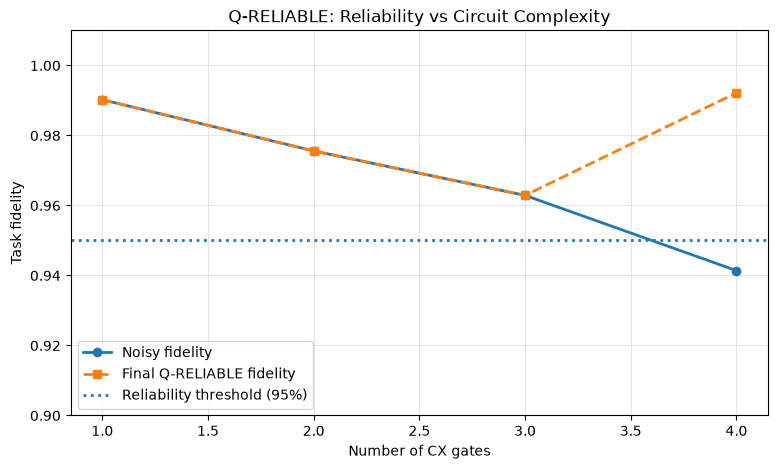

In [91]:
# ---------------------------------------------------------
# Phase 5.3: Final Q-RELIABLE Reliability Graph
# ---------------------------------------------------------

import matplotlib.pyplot as plt

# Extract the number of CX gates from the final summary.
cx_values = final_summary["CX Gates"]

# Extract fidelity before mitigation.
before_values = final_summary["Noisy Fidelity"]

# Extract fidelity after the Q-RELIABLE decision.
after_values = final_summary["Final Fidelity"]

# Extract the configured reliability threshold.
threshold = final_summary["Threshold"].iloc[0]

# Create the figure.
plt.figure(figsize=(9, 5))

# Plot fidelity before mitigation.
plt.plot(
    cx_values,
    before_values,
    marker="o",
    linewidth=2,
    label="Noisy fidelity"
)

# Plot the final Q-RELIABLE fidelity.
plt.plot(
    cx_values,
    after_values,
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Final Q-RELIABLE fidelity"
)

# Add the reliability threshold.
plt.axhline(
    threshold,
    linestyle=":",
    linewidth=2,
    label="Reliability threshold (95%)"
)

# Add labels.
plt.xlabel("Number of CX gates")
plt.ylabel("Task fidelity")

# Add title.
plt.title(
    "Q-RELIABLE: Reliability vs Circuit Complexity"
)

# Set a focused y-axis range so the differences are visible.
plt.ylim(0.90, 1.01)

# Add grid lines.
plt.grid(
    True,
    alpha=0.3
)

# Add legend.
plt.legend()

# Display the graph.
plt.show()

In [92]:
# ---------------------------------------------------------
# Phase 5.4: Capture Q-RELIABLE Environment Versions
# ---------------------------------------------------------

# Import the main libraries used by the project.
import qiskit
import qiskit_aer
import numpy
import pandas
import matplotlib

# Display the exact versions used by the working notebook.
print("===== Q-RELIABLE ENVIRONMENT =====")

print("Python version:")
import sys
print(sys.version)

print()

print("Qiskit version:", qiskit.__version__)
print("Qiskit Aer version:", qiskit_aer.__version__)
print("NumPy version:", numpy.__version__)
print("Pandas version:", pandas.__version__)
print("Matplotlib version:", matplotlib.__version__)

===== Q-RELIABLE ENVIRONMENT =====
Python version:
3.11.17 | packaged by Anaconda, Inc. | (main, Oct  1 2026, 20:16:54) [MSC v.1942 64 bit (AMD64)]

Qiskit version: 2.5.2
Qiskit Aer version: 0.17.2
NumPy version: 2.4.6
Pandas version: 3.0.6
Matplotlib version: 3.11.2


In [93]:
# ---------------------------------------------------------
# Phase 5.5: Generate requirements.txt
# ---------------------------------------------------------

# These are the exact package versions used by Q-RELIABLE.
requirements = """qiskit==2.5.2
qiskit-aer==0.17.2
numpy==2.4.6
pandas==3.0.6
matplotlib==3.11.2
"""

# Write the dependency list to a text file.
with open("requirements.txt", "w") as file:
    file.write(requirements)

print("requirements.txt created successfully.")
print()
print(requirements)

requirements.txt created successfully.

qiskit==2.5.2
qiskit-aer==0.17.2
numpy==2.4.6
pandas==3.0.6
matplotlib==3.11.2



In [95]:
# ---------------------------------------------------------
# Verify requirements.txt
# ---------------------------------------------------------

import os

# Check whether the file exists in the notebook's current folder.
print("File exists:", os.path.exists("requirements.txt"))

# Show the exact location where the file was created.
print("File location:", os.path.abspath("requirements.txt"))

# Read and display the contents of the file.
with open("requirements.txt", "r") as file:
    print("\n===== requirements.txt =====")
    print(file.read())

File exists: True
File location: C:\Users\sir\Quantum-RELIABLE\requirements.txt

===== requirements.txt =====
qiskit==2.5.2
qiskit-aer==0.17.2
numpy==2.4.6
pandas==3.0.6
matplotlib==3.11.2



In [96]:
# ---------------------------------------------------------
# Phase 5.6: Final Q-RELIABLE Validation
# ---------------------------------------------------------

print("=" * 60)
print("Q-RELIABLE FINAL VALIDATION")
print("=" * 60)

# Check that the main circuits exist.
print("\n[1] Circuit validation")
print("Bell circuit :", "PASS" if "bell" in globals() else "FAIL")
print("GHZ-3 circuit:", "PASS" if "ghz" in globals() else "FAIL")
print("GHZ-5 circuit:", "PASS" if "ghz5" in globals() else "FAIL")

# Check that the unified Q-RELIABLE pipeline exists.
print("\n[2] Pipeline validation")
print(
    "Q-RELIABLE engine:",
    "PASS" if "run_q_reliable" in globals() else "FAIL"
)

# Check that the final summary table exists.
print("\n[3] Results validation")
print(
    "Final summary:",
    "PASS" if "final_summary" in globals() else "FAIL"
)

# Check the dependency file.
import os

print("\n[4] Reproducibility validation")
print(
    "requirements.txt:",
    "PASS" if os.path.exists("requirements.txt") else "FAIL"
)

# Display the final project results.
print("\n[5] Final results")
print(final_summary.to_string(index=False))

print("\n" + "=" * 60)
print("VALIDATION COMPLETE")
print("=" * 60)

Q-RELIABLE FINAL VALIDATION

[1] Circuit validation
Bell circuit : PASS
GHZ-3 circuit: PASS
GHZ-5 circuit: PASS

[2] Pipeline validation
Q-RELIABLE engine: PASS

[3] Results validation
Final summary: PASS

[4] Reproducibility validation
requirements.txt: PASS

[5] Final results
Circuit  Qubits  CX Gates  Noisy Fidelity  Threshold      Decision  Final Fidelity  Fidelity Gain
   Bell       2         1        0.990234       0.95 NO_MITIGATION        0.990234       0.000000
  GHZ-3       3         2        0.975586       0.95 NO_MITIGATION        0.975586       0.000000
  GHZ-4       4         3        0.962891       0.95 NO_MITIGATION        0.962891       0.000000
  GHZ-5       5         4        0.941406       0.95      MITIGATE        0.992187       0.050781

VALIDATION COMPLETE


In [97]:
# ---------------------------------------------------------
# Phase 6.1A: Create results directory
# ---------------------------------------------------------

import os

# Define the folder where final project figures will be stored.
results_folder = "results"

# Create the folder if it does not already exist.
os.makedirs(results_folder, exist_ok=True)

# Verify that the folder exists.
print("Results folder exists:", os.path.exists(results_folder))
print("Location:", os.path.abspath(results_folder))

Results folder exists: True
Location: C:\Users\sir\Quantum-RELIABLE\results


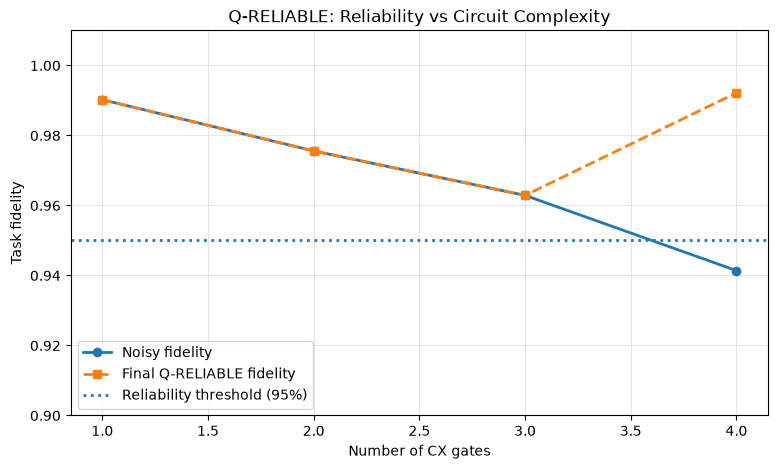

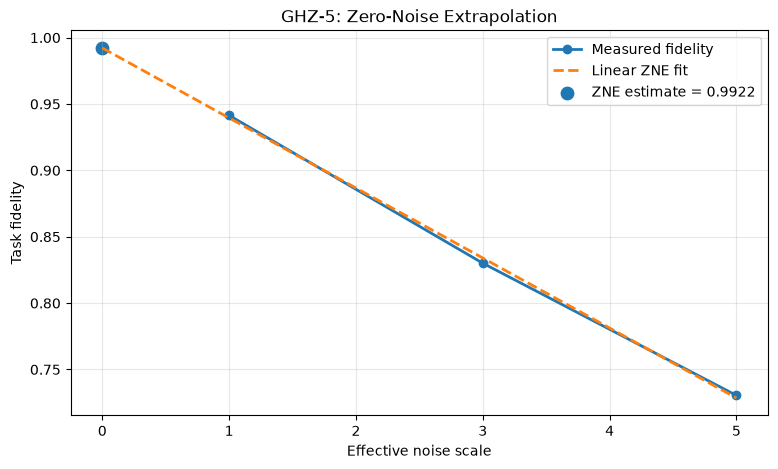

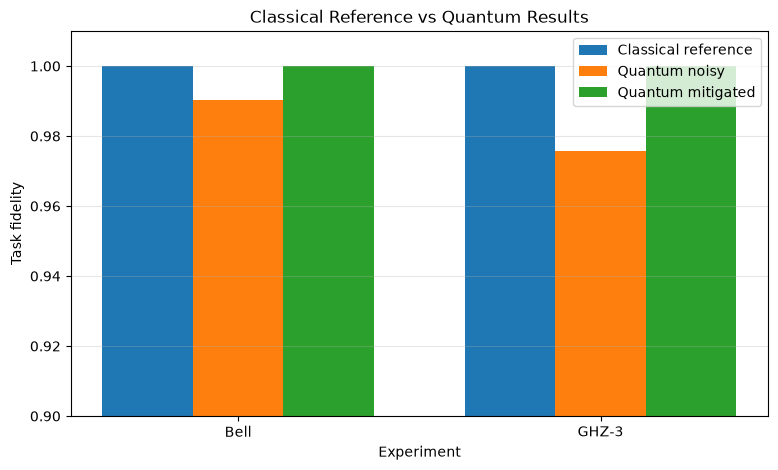


===== SAVED RESULT FILES =====
reliability_vs_complexity.png -> SAVED
zne_ghz5.png -> SAVED
classical_vs_quantum.png -> SAVED


In [98]:
# ---------------------------------------------------------
# Phase 6.1B: Save Final Q-RELIABLE Graphs
# ---------------------------------------------------------

import matplotlib.pyplot as plt
import os

# Make sure the results directory exists.
os.makedirs("results", exist_ok=True)


# =========================================================
# GRAPH 1 — Reliability vs Circuit Complexity
# =========================================================

cx_values = final_summary["CX Gates"]
before_values = final_summary["Noisy Fidelity"]
after_values = final_summary["Final Fidelity"]
threshold = final_summary["Threshold"].iloc[0]

plt.figure(figsize=(9, 5))

# Plot fidelity before mitigation.
plt.plot(
    cx_values,
    before_values,
    marker="o",
    linewidth=2,
    label="Noisy fidelity"
)

# Plot final Q-RELIABLE fidelity.
plt.plot(
    cx_values,
    after_values,
    marker="s",
    linewidth=2,
    linestyle="--",
    label="Final Q-RELIABLE fidelity"
)

# Show the configured reliability threshold.
plt.axhline(
    threshold,
    linestyle=":",
    linewidth=2,
    label="Reliability threshold (95%)"
)

plt.xlabel("Number of CX gates")
plt.ylabel("Task fidelity")
plt.title("Q-RELIABLE: Reliability vs Circuit Complexity")
plt.ylim(0.90, 1.01)
plt.grid(True, alpha=0.3)
plt.legend()

# Save the figure as a high-resolution PNG.
plt.savefig(
    "results/reliability_vs_complexity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Close the figure to avoid unnecessary memory usage.
plt.close()


# =========================================================
# GRAPH 2 — GHZ-5 ZNE Mitigation
# =========================================================

# Retrieve the GHZ-5 ZNE measurements.
zne_scales = ghz5_zne_results["noise_scales"]
zne_fidelities = ghz5_zne_results["fidelities"]
zne_slope = ghz5_zne_results["slope"]
zne_intercept = ghz5_zne_results["raw_zne_fidelity"]

plt.figure(figsize=(9, 5))

# Plot measured fidelity at each noise scale.
plt.plot(
    zne_scales,
    zne_fidelities,
    marker="o",
    linewidth=2,
    label="Measured fidelity"
)

# Generate points for the fitted linear ZNE model.
import numpy as np

fit_x = np.linspace(0, 5, 100)
fit_y = zne_slope * fit_x + zne_intercept

plt.plot(
    fit_x,
    fit_y,
    linestyle="--",
    linewidth=2,
    label="Linear ZNE fit"
)

# Mark the extrapolated zero-noise estimate.
plt.scatter(
    [0],
    [zne_intercept],
    s=80,
    label=f"ZNE estimate = {zne_intercept:.4f}"
)

plt.xlabel("Effective noise scale")
plt.ylabel("Task fidelity")
plt.title("GHZ-5: Zero-Noise Extrapolation")
plt.grid(True, alpha=0.3)
plt.legend()

# Save the figure.
plt.savefig(
    "results/zne_ghz5.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# =========================================================
# GRAPH 3 — Classical vs Quantum Comparison
# =========================================================

# Use the comparison table created during Phase 3.
experiments = comparison_df["Experiment"]

classical_values = comparison_df["Classical Reference"]
noisy_values = comparison_df["Quantum Noisy"]
mitigated_values = comparison_df["Quantum Mitigated"]

x = np.arange(len(experiments))
width = 0.25

plt.figure(figsize=(9, 5))

# Plot the classical reference.
plt.bar(
    x - width,
    classical_values,
    width,
    label="Classical reference"
)

# Plot noisy quantum results.
plt.bar(
    x,
    noisy_values,
    width,
    label="Quantum noisy"
)

# Plot mitigated quantum results.
plt.bar(
    x + width,
    mitigated_values,
    width,
    label="Quantum mitigated"
)

plt.xlabel("Experiment")
plt.ylabel("Task fidelity")
plt.title("Classical Reference vs Quantum Results")
plt.xticks(x, experiments)
plt.ylim(0.90, 1.01)
plt.grid(axis="y", alpha=0.3)
plt.legend()

# Save the figure.
plt.savefig(
    "results/classical_vs_quantum.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()


# =========================================================
# VERIFY FILES
# =========================================================

print("\n===== SAVED RESULT FILES =====")

for filename in [
    "reliability_vs_complexity.png",
    "zne_ghz5.png",
    "classical_vs_quantum.png"
]:
    filepath = os.path.join("results", filename)

    print(
        filename,
        "->",
        "SAVED" if os.path.exists(filepath) else "MISSING"
    )

In [100]:
# ---------------------------------------------------------
# Phase 6.2A: Create README.md safely
# ---------------------------------------------------------

# Build the README as a list of individual lines.
# This avoids problems with a very large triple-quoted string.

readme_lines = [
    "# Q-RELIABLE",
    "",
    "### Noise-Aware Reliability Engineering for Quantum Circuits",
    "",
    "Q-RELIABLE is a Qiskit-based noise-aware quantum reliability workflow "
    "designed to evaluate how circuit complexity affects task-level fidelity "
    "and automatically determine when mitigation should be applied.",
    "",
    "Instead of blindly applying mitigation to every circuit, Q-RELIABLE "
    "follows an engineering workflow:",
    "",
    "**Circuit Characterization → Controlled Noise Injection → "
    "Reliability Measurement → Mitigation Decision → ZNE Mitigation → "
    "Reliability Report**",
    "",
    "---",
    "",
    "## 1. Problem Statement",
    "",
    "Quantum circuits executed on noisy quantum hardware or realistic "
    "simulators can produce results that deviate from their expected outcomes.",
    "",
    "A practical quantum software engineer therefore needs to answer:",
    "",
    "- How sensitive is a circuit to noise?",
    "- How does circuit complexity affect reliability?",
    "- When should mitigation be applied?",
    "- Does mitigation actually improve the result?",
    "- What is the measurement overhead of mitigation?",
    "",
    "Q-RELIABLE addresses these questions using a controlled Qiskit Aer "
    "noise model and a configurable reliability threshold.",
    "",
    "---",
    "",
    "## 2. Key Idea",
    "",
    "Q-RELIABLE treats quantum error mitigation as a **reliability "
    "engineering problem** rather than simply applying mitigation blindly.",
    "",
    "The workflow is:",
    "",
    "```text",
    "Input Circuit",
    "     ↓",
    "Circuit Analyzer",
    "     ↓",
    "Circuit + Noise Metrics",
    "     ↓",
    "Reliability Score",
    "     ↓",
    "Is Fidelity < Threshold?",
    "    /              \\",
    "  No                Yes",
    "  │                  │",
    "  ▼                  ▼",
    "Keep Result       Apply ZNE",
    "  │                  │",
    "  └────────┬─────────┘",
    "           ▼",
    "    Final Reliability",
    "           │",
    "           ▼",
    "    Reliability Report",
    "```",
    "",
    "---",
    "",
    "## 3. Implementation",
    "",
    "### Technology Stack",
    "",
    "- Python 3.11",
    "- Qiskit 2.5.2",
    "- Qiskit Aer 0.17.2",
    "- NumPy 2.4.6",
    "- Pandas 3.0.6",
    "- Matplotlib 3.11.2",
    "",
    "### Quantum Circuits",
    "",
    "The project evaluates:",
    "",
    "- Bell state circuit",
    "- GHZ-3 circuit",
    "- GHZ-4 circuit",
    "- GHZ-5 circuit",
    "",
    "The circuits progressively increase in the number of two-qubit CX "
    "gates, allowing controlled investigation of circuit complexity "
    "and reliability.",
    "",
    "---",
    "",
    "## 4. Controlled Noise Model",
    "",
    "The experiments use a synthetic Qiskit Aer noise model.",
    "",
    "A 2% depolarizing error is applied to CX gates.",
    "",
    "```python",
    "NOISE_PROBABILITY = 0.02",
    "```",
    "",
    "The noise model is intentionally controlled so that the effect of "
    "increasing two-qubit-gate complexity can be measured consistently.",
    "",
    "> This is a simulation model, not a claim about the physical error "
    "rate of a particular quantum processor.",
    "",
    "---",
    "",
    "## 5. Reliability Metric",
    "",
    "Q-RELIABLE uses **task-level fidelity** for the selected experiments.",
    "",
    "For the Bell state, the expected outcomes are `00` and `11`.",
    "",
    "For GHZ circuits, the expected outcomes are `000...0` and `111...1`.",
    "",
    "The metric is:",
    "",
    "```text",
    "Fidelity = Number of expected outcomes / Total shots",
    "```",
    "",
    "> This is a task-level measurement fidelity, not full quantum-state "
    "fidelity.",
    "",
    "---",
    "",
    "## 6. Automatic Mitigation Decision",
    "",
    "The configured reliability threshold is **0.95 (95%)**.",
    "",
    "```text",
    "If fidelity >= 0.95 → NO_MITIGATION",
    "If fidelity < 0.95  → MITIGATE",
    "```",
    "",
    "The threshold is a prototype engineering parameter and is not "
    "intended to be a universal reliability threshold for quantum hardware.",
    "",
    "---",
    "",
    "## 7. Zero-Noise Extrapolation",
    "",
    "When mitigation is required, Q-RELIABLE applies a simple "
    "Zero-Noise Extrapolation (ZNE) workflow.",
    "",
    "The effective noise scales used are:",
    "",
    "- 1×",
    "- 3×",
    "- 5×",
    "",
    "The measured fidelities are fitted using a linear model and "
    "extrapolated toward zero noise.",
    "",
    "The project reports both the raw ZNE extrapolation and the "
    "physically bounded value in the range [0, 1].",
    "",
    "---",
    "",
    "## 8. Experimental Results",
    "",
    "| Circuit | CX Gates | Noisy Fidelity | Decision | Final Fidelity |",
    "|---|---:|---:|---|---:|",
    "| Bell | 1 | 99.0234% | NO_MITIGATION | 99.0234% |",
    "| GHZ-3 | 2 | 97.5586% | NO_MITIGATION | 97.5586% |",
    "| GHZ-4 | 3 | 96.2891% | NO_MITIGATION | 96.2891% |",
    "| GHZ-5 | 4 | 94.1406% | MITIGATE | 99.2187% |",
    "",
    "### GHZ-5 result",
    "",
    "- Before mitigation: **94.1406%**",
    "- After ZNE: **99.2187%**",
    "- Absolute improvement: **5.0781 percentage points**",
    "- ZNE shot budget: **3× baseline**",
    "",
    "---",
    "",
    "## 9. Results",
    "",
    "### Reliability vs Circuit Complexity",
    "",
    "![Reliability vs Circuit Complexity](results/reliability_vs_complexity.png)",
    "",
    "The controlled experiment shows decreasing task-level fidelity as "
    "the number of CX gates increases. Under the selected noise model, "
    "GHZ-5 crosses the configured reliability threshold and triggers mitigation.",
    "",
    "### GHZ-5 Zero-Noise Extrapolation",
    "",
    "![GHZ-5 ZNE](results/zne_ghz5.png)",
    "",
    "The measured fidelity decreases as the effective noise scale increases. "
    "Linear extrapolation estimates the zero-noise fidelity.",
    "",
    "### Classical Reference Comparison",
    "",
    "![Classical vs Quantum](results/classical_vs_quantum.png)",
    "",
    "The classical reference represents an ideal-output correctness baseline "
    "for the selected Bell and GHZ tasks.",
    "",
    "> This is not a runtime or computational-performance comparison and "
    "does not claim quantum advantage.",
    "",
    "---",
    "",
    "## 10. Engineering Insights",
    "",
    "1. Increasing CX-gate complexity can reduce task-level fidelity "
    "under noise.",
    "2. A reliability threshold can be used to trigger mitigation automatically.",
    "3. Mitigation should not necessarily be applied to every circuit.",
    "4. ZNE can recover a significant portion of the observed error in "
    "the GHZ-5 experiment.",
    "5. Mitigation introduces additional measurement cost.",
    "6. Reliability and mitigation effectiveness should be reported "
    "together with their overhead.",
    "",
    "---",
    "",
    "## 11. Limitations",
    "",
    "- Results are simulator-based.",
    "- No real IBM Quantum hardware result is claimed.",
    "- The 2% depolarizing parameter is synthetic.",
    "- The 95% threshold is configurable and illustrative.",
    "- Task-level fidelity is not full state fidelity.",
    "- ZNE is demonstrated as an engineering technique rather than "
    "proposed as a novel algorithm.",
    "- The classical comparison is an ideal-output reference rather "
    "than a computational-speed benchmark.",
    "- No claim of quantum advantage is made.",
    "",
    "---",
    "",
    "## 12. Reproducibility",
    "",
    "Clone the repository:",
    "",
    "```bash",
    "git clone <YOUR_GITHUB_REPOSITORY_URL>",
    "cd Quantum-RELIABLE",
    "```",
    "",
    "Create the environment:",
    "",
    "```bash",
    "conda create -n q-reliable python=3.11",
    "conda activate q-reliable",
    "```",
    "",
    "Install the tested dependencies:",
    "",
    "```bash",
    "pip install -r requirements.txt",
    "```",
    "",
    "Launch Jupyter:",
    "",
    "```bash",
    "jupyter notebook",
    "```",
    "",
    "Open `Q_RELIABLE_Phase1_Bell_Noise.ipynb` and run the notebook "
    "from top to bottom.",
    "",
    "---",
    "",
    "## 13. Project Structure",
    "",
    "```text",
    "Quantum-RELIABLE/",
    "│",
    "├── Q_RELIABLE_Phase1_Bell_Noise.ipynb",
    "├── requirements.txt",
    "├── README.md",
    "│",
    "└── results/",
    "    ├── reliability_vs_complexity.png",
    "    ├── zne_ghz5.png",
    "    └── classical_vs_quantum.png",
    "```",
    "",
    "---",
    "",
    "## 14. Conclusion",
    "",
    "Q-RELIABLE demonstrates a practical noise-aware engineering "
    "workflow for quantum circuits.",
    "",
    "Rather than assuming mitigation is always beneficial, the system:",
    "",
    "**Characterizes → Measures → Decides → Mitigates → Reports**",
    "",
    "This makes reliability, mitigation benefit, and measurement overhead "
    "visible to the quantum software engineer.",
    "",
    "The current implementation is a simulator-based proof of concept "
    "designed to be extended to additional noise models, hardware "
    "backends, circuit families, and mitigation techniques.",
    "",
    "---",
    "",
    "## 15. Hackathon Alignment",
    "",
    "**Challenge:** I7 — Noise-Aware Engineering",
    "",
    "**Role:** Quantum Software Engineer",
    "",
    "**Primary Qiskit components:**",
    "",
    "- Qiskit QuantumCircuit",
    "- Qiskit transpilation",
    "- Qiskit AerSimulator",
    "- Qiskit Aer noise models",
    "- Depolarizing errors",
    "- Zero-Noise Extrapolation workflow",
]

# Join all lines into one README document.
readme_content = "\n".join(readme_lines)

# Write the README file.
with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_content)

print("README.md created successfully.")
print("Location:", os.path.abspath("README.md"))

README.md created successfully.
Location: C:\Users\sir\Quantum-RELIABLE\README.md


In [101]:
# ---------------------------------------------------------
# Phase 6.2B: Verify README.md
# ---------------------------------------------------------

import os

# Check that README.md exists.
print("README exists:", os.path.exists("README.md"))

# Get the exact file location.
print("README location:", os.path.abspath("README.md"))

# Read the README and perform a few basic checks.
with open("README.md", "r", encoding="utf-8") as file:
    readme_text = file.read()

print("\nREADME size:", len(readme_text), "characters")

print("\n===== README CHECKS =====")

# Check for important project sections.
checks = {
    "Project title": "# Q-RELIABLE" in readme_text,
    "Problem statement": "## 1. Problem Statement" in readme_text,
    "Implementation": "## 3. Implementation" in readme_text,
    "Noise model": "## 4. Controlled Noise Model" in readme_text,
    "Reliability metric": "## 5. Reliability Metric" in readme_text,
    "Mitigation decision": "## 6. Automatic Mitigation Decision" in readme_text,
    "ZNE": "## 7. Zero-Noise Extrapolation" in readme_text,
    "Experimental results": "## 8. Experimental Results" in readme_text,
    "Limitations": "## 11. Limitations" in readme_text,
    "Reproducibility": "## 12. Reproducibility" in readme_text,
    "Project structure": "## 13. Project Structure" in readme_text,
    "Hackathon alignment": "## 15. Hackathon Alignment" in readme_text,
}

# Display the result of every check.
for check_name, passed in checks.items():
    print(
        f"{check_name}:",
        "PASS" if passed else "FAIL"
    )

print("\n===== RESULT FILE REFERENCES =====")

# Verify that all three figures referenced by the README exist.
result_files = [
    "results/reliability_vs_complexity.png",
    "results/zne_ghz5.png",
    "results/classical_vs_quantum.png",
]

for filepath in result_files:
    print(
        filepath,
        "->",
        "PASS" if os.path.exists(filepath) else "FAIL"
    )

README exists: True
README location: C:\Users\sir\Quantum-RELIABLE\README.md

README size: 7453 characters

===== README CHECKS =====
Project title: PASS
Problem statement: PASS
Implementation: PASS
Noise model: PASS
Reliability metric: PASS
Mitigation decision: PASS
ZNE: PASS
Experimental results: PASS
Limitations: PASS
Reproducibility: PASS
Project structure: PASS
Hackathon alignment: PASS

===== RESULT FILE REFERENCES =====
results/reliability_vs_complexity.png -> PASS
results/zne_ghz5.png -> PASS
results/classical_vs_quantum.png -> PASS
